## Mutation Testing on Mistral LLM

Using the code generation database from the MongoDB, this notebook will run **zero shot, one shot** and **few shot prompts** on a Mistral LLM. Each prompt technique also includes **no mutation, sequential mutated** and **random mutated** programs. In total, 9 experiments are run through this notebook. All logs are stored in csv files automatically for your analysis.

In [ ]:
import os
import sys

In [ ]:
curr_dir = os.getcwd()
parent_dir = os.path.dirname(curr_dir)
proj_dir = os.path.dirname(parent_dir)
sys.path.append(proj_dir)

In [ ]:
from code_generation.code_generation_tester import CodeGenerationTester
from code_generation.prompt_templates.prompt_template import OpenEndedPromptTemplate
from utility.constants import BigCodeBench, HumanEval, LexicalMutations, SyntacticMutations, LogicalMutations, PromptTypes, CodeGeneration, ReasoningModels, NonReasoningModels

In [ ]:
## Declaring Prompt Type Constants
ZERO_SHOT = PromptTypes.ZERO_SHOT
ONE_SHOT = PromptTypes.ONE_SHOT
FEW_SHOT = PromptTypes.FEW_SHOT

## Declaring Mutation Constants
RANDOM_MUTATION = LexicalMutations.RANDOM
SEQUENTIAL_MUTATION = LexicalMutations.SEQUENTIAL
LITERAL_FORMAT = LexicalMutations.LITERAL_FORMAT

## Declaring Benchmark Name Constants
BIGCODEBENCH = BigCodeBench.NAME
HUMANEVAL = HumanEval.NAME

## Declaring Reasoning Model Name Constants
GPT5 = ReasoningModels.GPT5['name']
GPT4O_REASONING = ReasoningModels.GPT4O_REASONING['name']

## Declaring Non-Reasoning Model Name Constants
MISTRAL = NonReasoningModels.MISTRAL_SMALL_LATEST['name']
GPT4O = NonReasoningModels.GPT4O['name']

In [ ]:
reasoning_models = [getattr(ReasoningModels, model) for model in dir(ReasoningModels) if not model.startswith("_")]
non_reasoning_models = [getattr(NonReasoningModels, model) for model in dir(NonReasoningModels) if not model.startswith("_")]
print('Reasoning models supported by this framework are:')
for idx, model in enumerate(reasoning_models):
    print(f"{idx+1}: '{model['name']}'")
print('=' * 50)
print('Non-reasoning models supported by this framework are:')
for idx, model in enumerate(non_reasoning_models):
    print(f"{idx+1}: '{model['name']}'")

Reasoning models supported by this framework are:
1: 'gpt-4o-reasoning'
2: 'gpt-5'
Non-reasoning models supported by this framework are:
1: 'gpt-4o'
2: 'mistral-small-latest'


In [ ]:
task_set = BIGCODEBENCH

try:
    llmtester = CodeGenerationTester(f"{task_set}_Code_Generation")
except Exception as e:
    print(f'llmtester could not launch due to the following error: {e}')

In [ ]:
num_tests = llmtester.question_database.count_documents({})

In [ ]:
valid_mutations = CodeGeneration.MUTATIONS
print("These are the valid mutation names for code generation:")
for idx, mutation in enumerate(valid_mutations):
    if mutation != LITERAL_FORMAT:
        print(idx+1, mutation)

# Run your experiments

In [ ]:
# %%script false --no-raise-error
mutations = [SEQUENTIAL_MUTATION]
prompt_type = ONE_SHOT
model_name = GPT4O

# Forming the results directory
results_dir =os.path.join(proj_dir, f'results/code_generation/{model_name}')
os.makedirs(results_dir, exist_ok=True)

mutation_str = "_".join(mutations) if len(mutations) > 0 else "no_mutation"
output_file_path=f"{results_dir}/{task_set}_{prompt_type}_{mutation_str}.csv"

pass_count = llmtester.run_code_generation_test(
    prompt_helper = OpenEndedPromptTemplate().return_appropriate_prompt(prompt_type),
    num_tests=num_tests,
    mutations = mutations,
    prompt_type= prompt_type,
    output_file_path=output_file_path,
    task_set = task_set,
    model_name= model_name,
    continue_from_task="BigCodeBencho636"
)

print(fr"Results saved in {output_file_path}")


  0%|          | 0/477 [00:00<?, ?it/s][nltk_data] Downloading package stopwords to /Users/jin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/jin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


BigCodeBencho636: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_all_stopwords>, 'Traceback (most recent call last):\n  File "<string>", line 30, in test_all_stopwords\n  File "<string>", line 18, in generic_function1\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py", line 2104, in fit_transform\n    X = super().fit_transform(raw_documents)\n        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper\n    return fit_method(estimator, *args, **kwargs)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/feature

  0%|          | 1/477 [00:12<1:39:38, 12.56s/it][nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
  0%|          | 2/477 [00:23<1:32:02, 11.63s/it]

BigCodeBencho638: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_case_3>, 'Traceback (most recent call last):\n  File "<string>", line 19, in test_case_3\n  File "<string>", line 21, in generic_function1\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/gensim/models/word2vec.py", line 430, in __init__\n    self.train(\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/gensim/models/word2vec.py", line 1045, in train\n    self._check_training_sanity(epochs=epochs, total_examples=total_examples, total_words=total_words)\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/gensim/models/word2vec.py", line 1554, in _check_training_sanity\n    raise RuntimeError("you must first buil

  1%|          | 3/477 [00:35<1:33:50, 11.88s/it][nltk_data] Downloading package stopwords to /Users/jin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/jin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
  1%|▏         | 6/477 [01:06<1:23:28, 10.63s/it]

...

BigCodeBencho796: Function failed to run due to following error -> <class 'RuntimeError'>


 35%|███▍      | 166/477 [26:37<1:11:49, 13.86s/it]

BigCodeBencho802: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_case_3>, 'Traceback (most recent call last):\n  File "<string>", line 25, in test_case_3\n  File "<string>", line 8, in generic_function1\n  File "numpy/random/mtrand.pyx", line 1001, in numpy.random.mtrand.RandomState.choice\nValueError: Cannot take a larger sample than population when \'replace=False\'\n')]


 36%|███▌      | 170/477 [27:44<50:05,  9.79s/it]  

cannot access local variable 'e' where it is not associated with a value
BigCodeBencho806
Results saved in /Users/jin/Documents/GitHub/Code Reasoning Model Research Project/results/code_generation/gpt-4o/BigCodeBench_one_shot_sequential.csv


  0%|          | 0/594 [00:00<?, ?it/s]

BigCodeBencho519: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_base_conversion_and_hashing>, 'Traceback (most recent call last):\n  File "<string>", line 8, in test_base_conversion_and_hashing\n  File "<string>", line 33, in task_func\n  File "<string>", line 33, in <genexpr>\nTypeError: argument should be integer or bytes-like object, not \'str\'\n'), (<builtins.TestCases testMethod=test_different_salts_different_hashes>, 'Traceback (most recent call last):\n  File "<string>", line 12, in test_different_salts_different_hashes\n  File "<string>", line 33, in task_func\n  File "<string>", line 33, in <genexpr>\nTypeError: argument should be integer or bytes-like object, not \'str\'\n')]


  0%|          | 1/594 [00:11<1:48:49, 11.01s/it]

BigCodeBencho520: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_base_conversion_and_signing>, 'Traceback (most recent call last):\n  File "<string>", line 16, in test_base_conversion_and_signing\n  File "<string>", line 31, in task_func\n  File "<string>", line 31, in <genexpr>\nIndexError: string index out of range\n'), (<builtins.TestCases testMethod=test_different_numbers_produce_different_output>, 'Traceback (most recent call last):\n  File "<string>", line 20, in test_different_numbers_produce_different_output\n  File "<string>", line 31, in task_func\n  File "<string>", line 31, in <genexpr>\nIndexError: string index out of range\n'), (<builtins.TestCases testMethod=test_output_is_base64_encoded>, 'Traceback (most recent call last):\n  File "<string>", line 33, in test_output_is_base64_encoded\n  File "<string>", line 31, in task_func\n  Fi

  1%|          | 7/594 [01:20<1:51:24, 11.39s/it]

...

  1%|▏         | 8/594 [01:31<1:48:39, 11.12s/it]

BigCodeBencho527: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_module_path_in_sys_path>, 'Traceback (most recent call last):\n  File "<string>", line 34, in test_module_path_in_sys_path\n  File "<string>", line 18, in task_func\n  File "/Users/jin/anaconda3/lib/python3.11/importlib/__init__.py", line 126, in import_module\n    return _bootstrap._gcd_import(name[level:], package, level)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import\n  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load\n  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked\n  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked\n  File "<frozen importlib._bootstrap_external>", line 940, in exec_module\n  File "<frozen importlib._bootstrap>", li

  2%|▏         | 12/594 [02:10<1:40:58, 10.41s/it]

BigCodeBencho531: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


  3%|▎         | 20/594 [03:20<1:25:41,  8.96s/it]

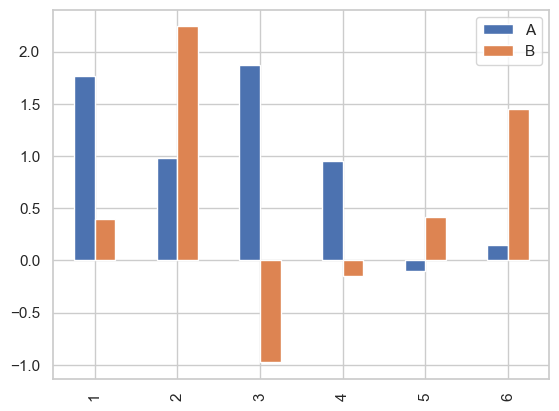

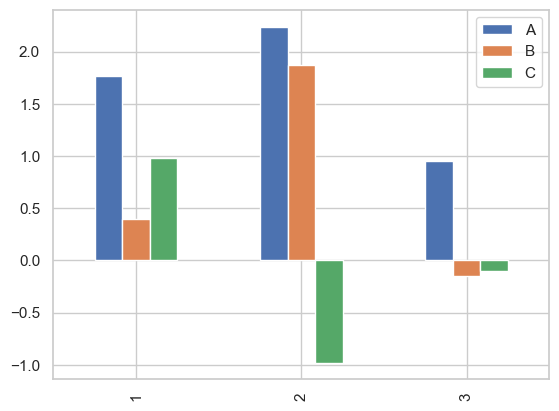

BigCodeBencho539: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_both_lists_empty>, 'Traceback (most recent call last):\n  File "<string>", line 18, in test_both_lists_empty\n  File "<string>", line 20, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/plotting/_core.py", line 1030, in __call__\n    return plot_backend.plot(data, kind=kind, **kwargs)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/plotting/_matplotlib/__init__.py", line 71, in plot\n    plot_obj.generate()\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py", line 499, in generate\n    sel

  4%|▎         | 22/594 [03:39<1:28:19,  9.27s/it]

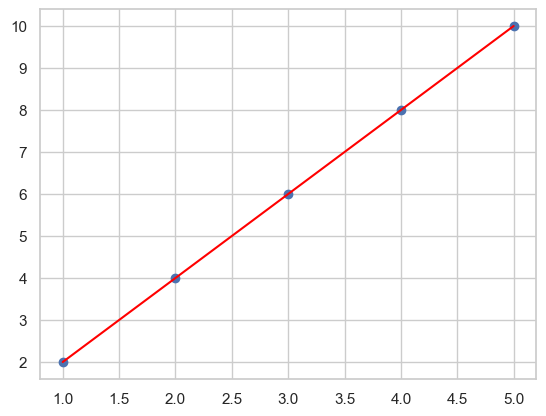

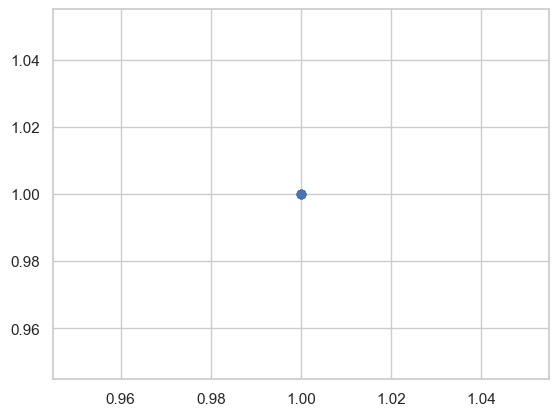

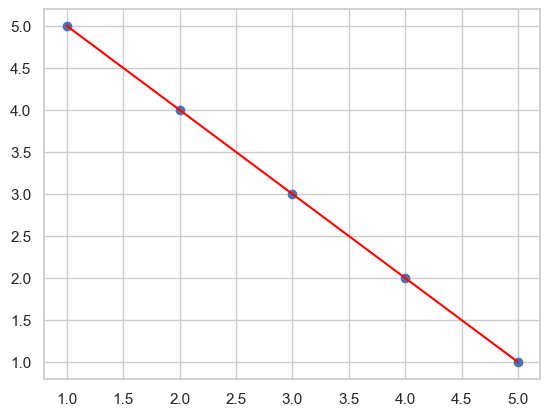

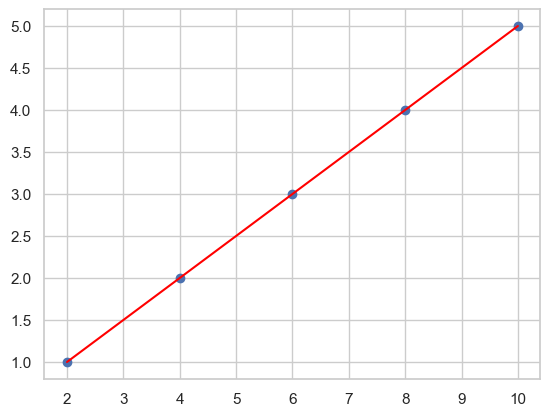

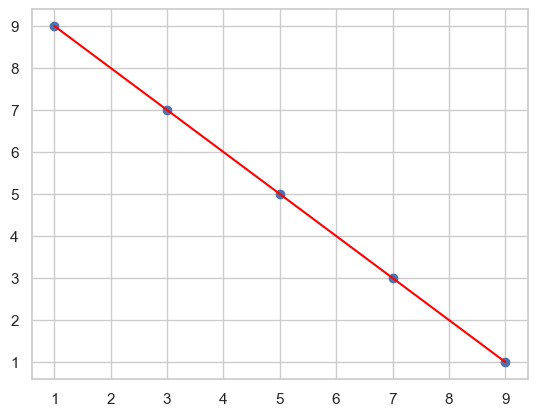

BigCodeBencho541: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_case_2>, 'Traceback (most recent call last):\n  File "<string>", line 10, in test_case_2\n  File "<string>", line 18, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/scipy/stats/_stats_mstats_common.py", line 157, in linregress\n    raise ValueError("Cannot calculate a linear regression "\nValueError: Cannot calculate a linear regression if all x values are identical\n')]


  4%|▍         | 25/594 [04:17<1:49:59, 11.60s/it]

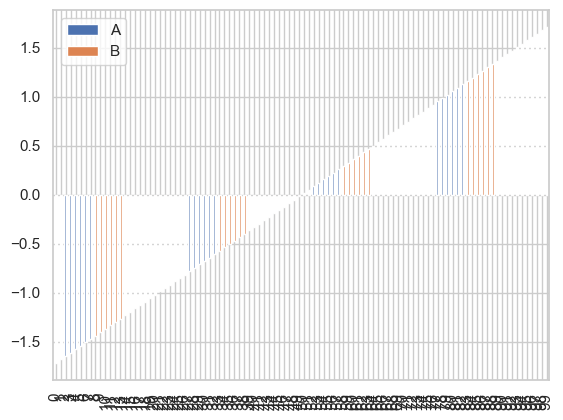

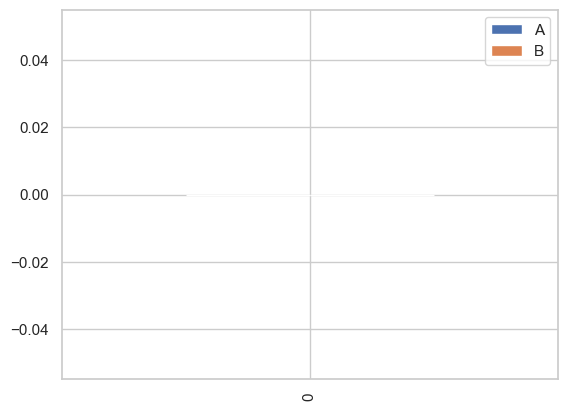

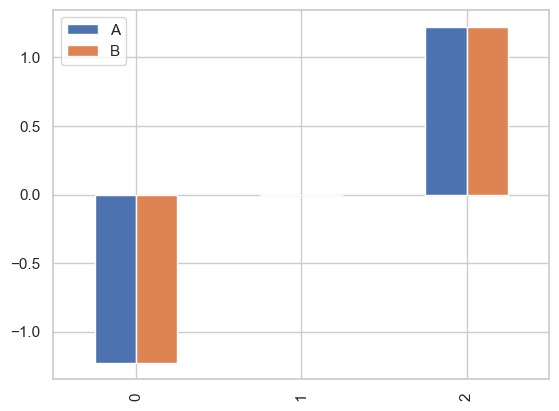

BigCodeBencho544: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_empty_lists>, 'Traceback (most recent call last):\n  File "<string>", line 12, in test_empty_lists\n  File "<string>", line 12, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/utils/_set_output.py", line 316, in wrapped\n    data_to_wrap = f(self, X, *args, **kwargs)\n                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/base.py", line 894, in fit_transform\n    return self.fit(X, **fit_params).transform(X)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py", line 907, i

  6%|▌         | 33/594 [05:37<1:28:48,  9.50s/it]

BigCodeBencho552: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_defaults_none>, 'Traceback (most recent call last):\n  File "<string>", line 25, in test_defaults_none\nKeyError: 0\n')]


  6%|▌         | 34/594 [05:46<1:25:49,  9.20s/it]

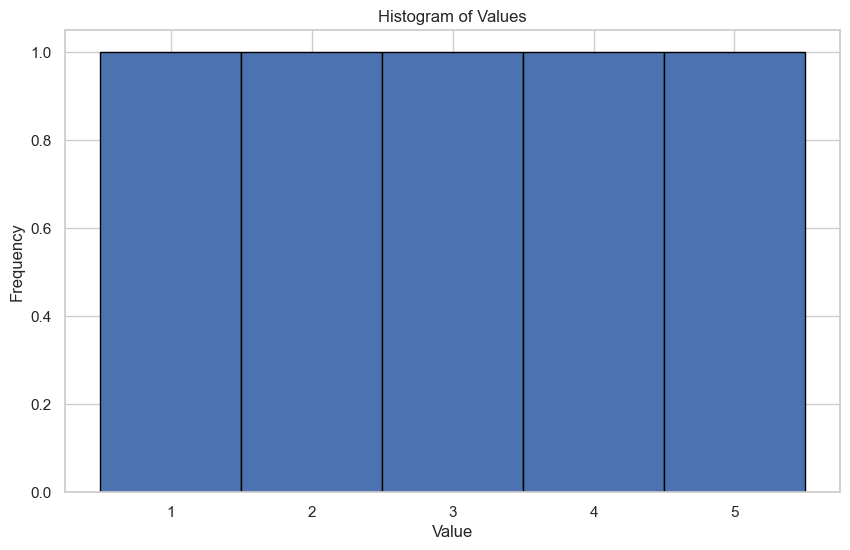

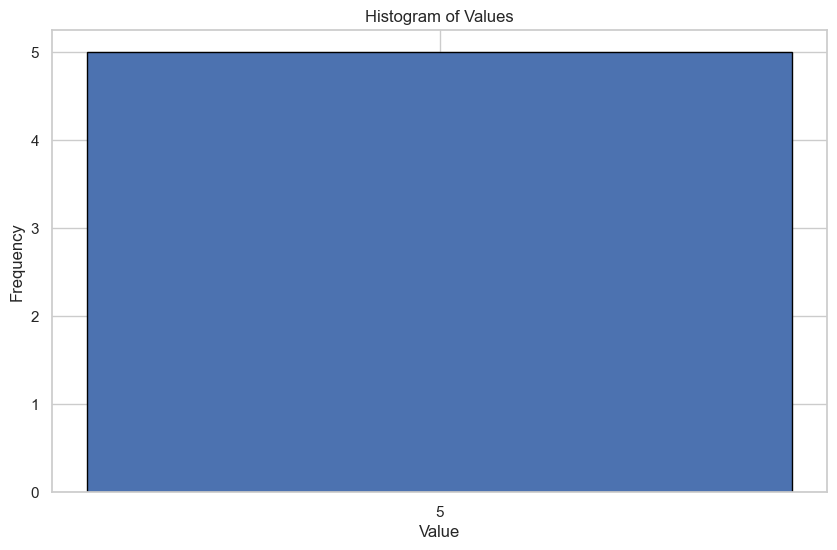

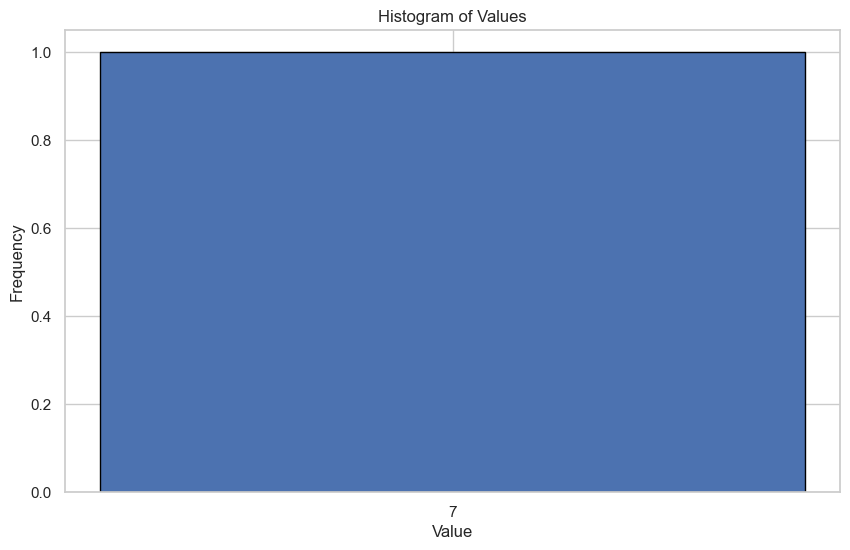

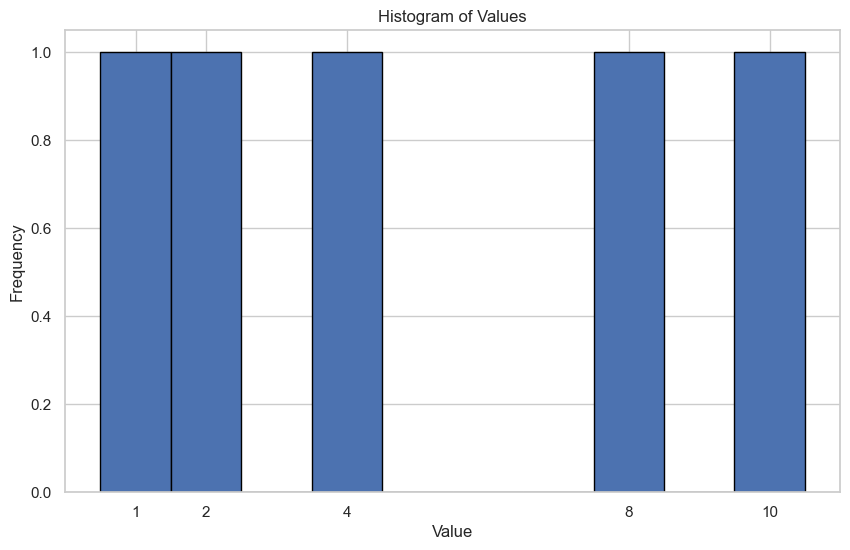

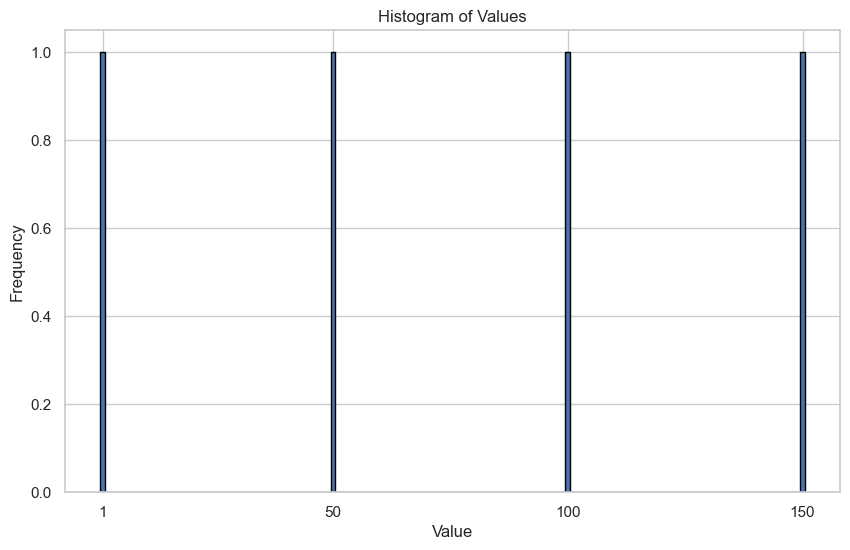

  6%|▌         | 35/594 [05:56<1:28:04,  9.45s/it]

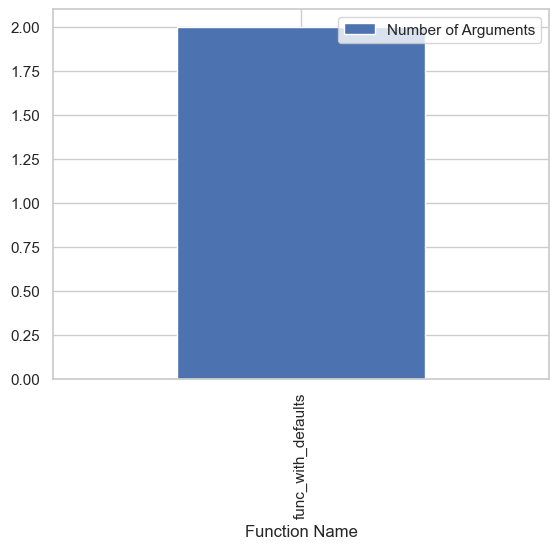

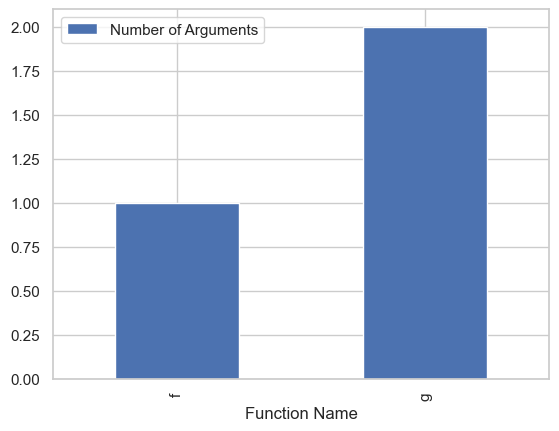

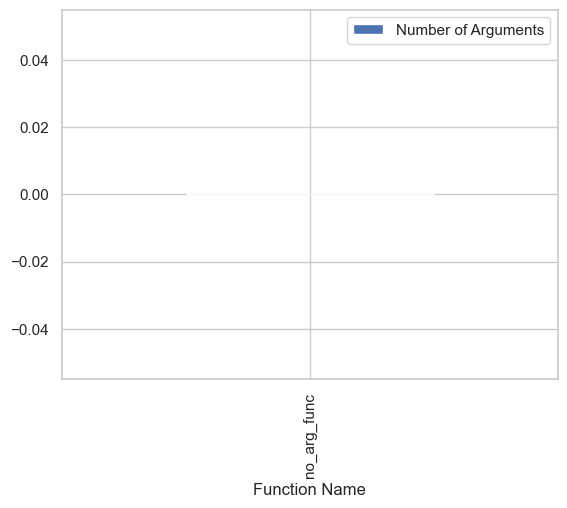

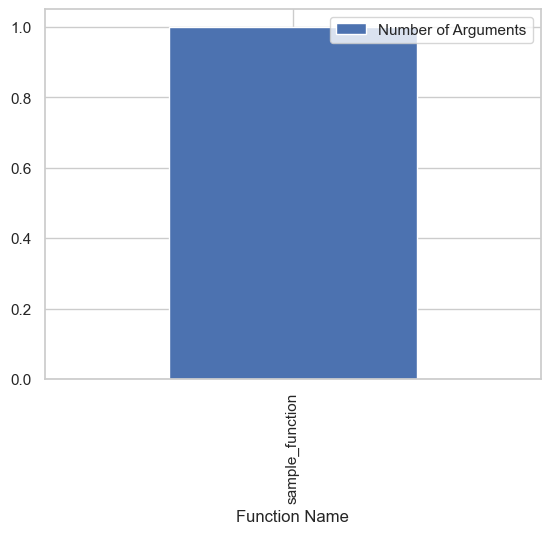

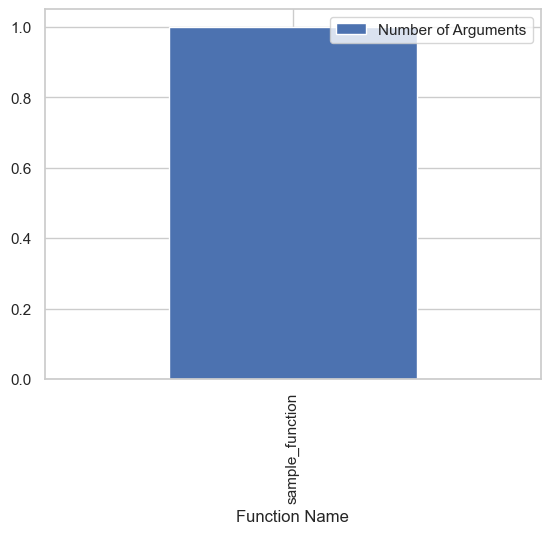

  6%|▌         | 37/594 [06:17<1:31:27,  9.85s/it]

BigCodeBencho556: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_function_name>, 'Traceback (most recent call last):\n  File "<string>", line 25, in test_function_name\nKeyError: \'function_name\'\n'), (<builtins.TestCases testMethod=test_lambda_function>, 'Traceback (most recent call last):\n  File "<string>", line 13, in test_lambda_function\nKeyError: \'function_name\'\n'), (<builtins.TestCases testMethod=test_regular_function>, 'Traceback (most recent call last):\n  File "<string>", line 7, in test_regular_function\nKeyError: \'function_name\'\n')]


  6%|▋         | 38/594 [06:27<1:32:27,  9.98s/it]

BigCodeBencho557: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_invalid_file_path>, 'Traceback (most recent call last):\n  File "<string>", line 33, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/util/_decorators.py", line 333, in wrapper\n    return func(*args, **kwargs)\n           ^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/core/generic.py", line 3986, in to_csv\n    return DataFrameRenderer(formatter).to_csv(\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/io/formats/format.py", line 1014, in to_csv\n    csv_formatter.save()\n  File "/Users/jin/Documents/

  7%|▋         | 39/594 [06:38<1:34:05, 10.17s/it]

...

  7%|▋         | 41/594 [06:55<1:25:41,  9.30s/it]

BigCodeBencho560: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


  7%|▋         | 42/594 [07:04<1:25:50,  9.33s/it]

BigCodeBencho561: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_empty_list>, 'Traceback (most recent call last):\n  File "<string>", line 14, in test_empty_list\n  File "<string>", line 8, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/core/frame.py", line 10381, in apply\n    return op.apply().__finalize__(self, method="apply")\n           ^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/core/apply.py", line 910, in apply\n    return self.apply_empty_result()\n           ^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/core/apply.py", line 983, in apply_empty_result\n    return self.obj._construct

  8%|▊         | 47/594 [07:53<1:31:59, 10.09s/it]

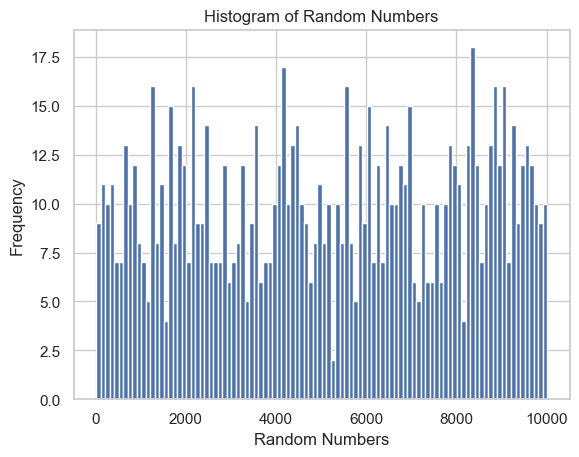

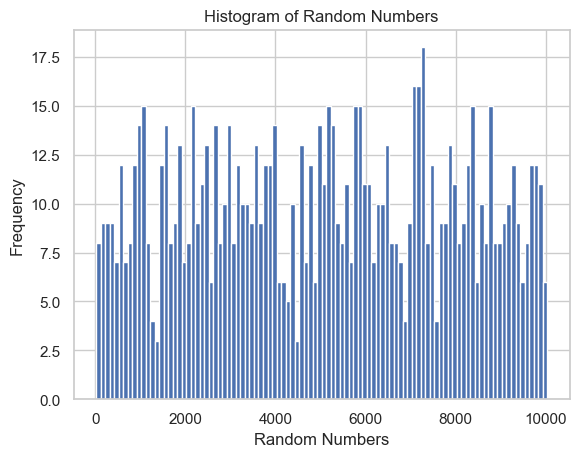

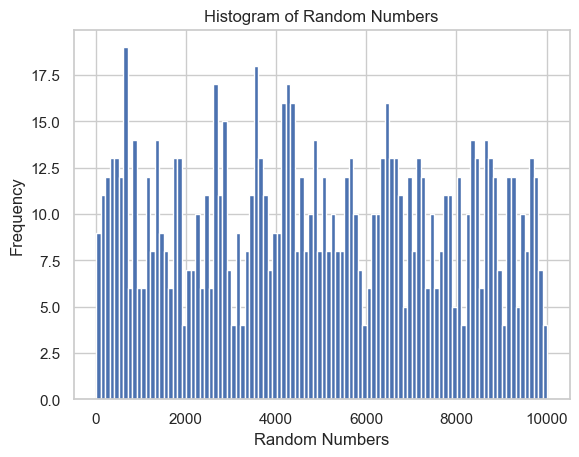

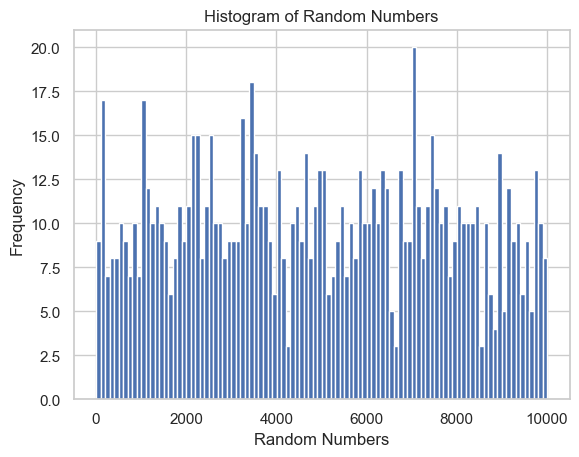

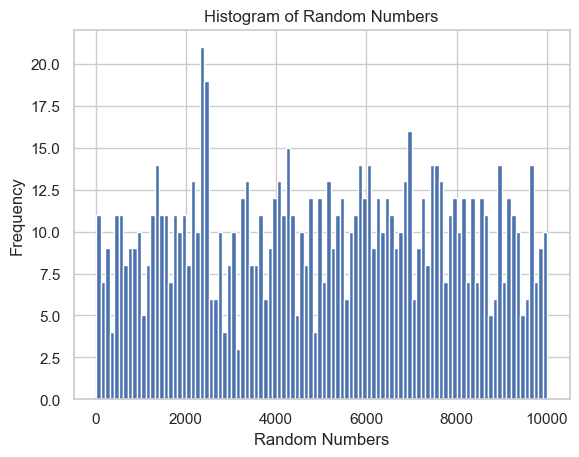

  8%|▊         | 48/594 [08:02<1:31:00, 10.00s/it]

BigCodeBencho567: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


  8%|▊         | 50/594 [08:20<1:26:01,  9.49s/it]

BigCodeBencho569: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


  9%|▊         | 51/594 [08:33<1:35:03, 10.50s/it]

...

  9%|▉         | 53/594 [09:01<1:45:53, 11.74s/it]

BigCodeBencho572: Function failed to run due to following error -> <class 'RuntimeError'>


  9%|▉         | 54/594 [09:20<2:06:27, 14.05s/it]

BigCodeBencho573: Function failed to run due to following error -> <class 'RuntimeError'>


  9%|▉         | 55/594 [09:38<2:16:31, 15.20s/it]

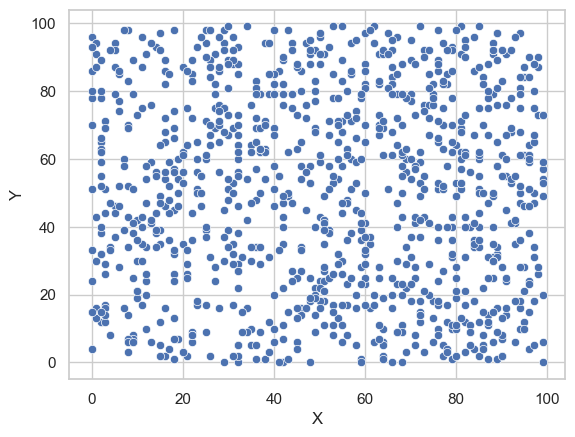

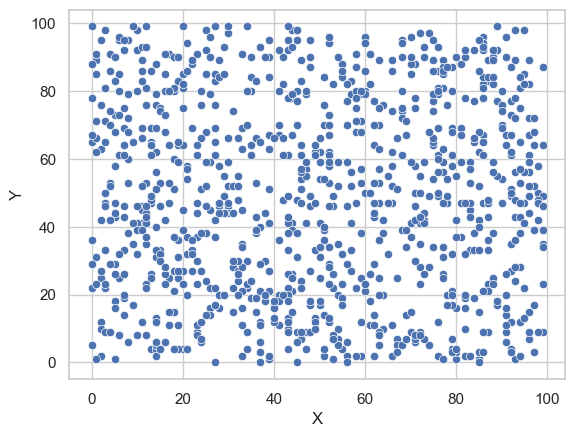

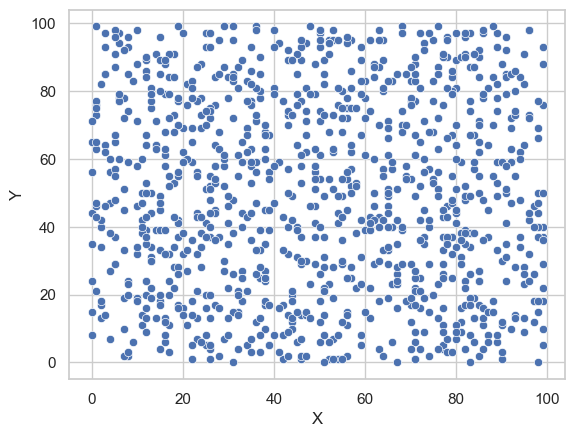

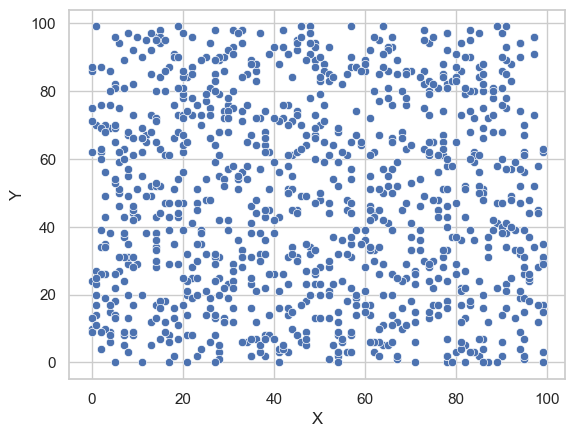

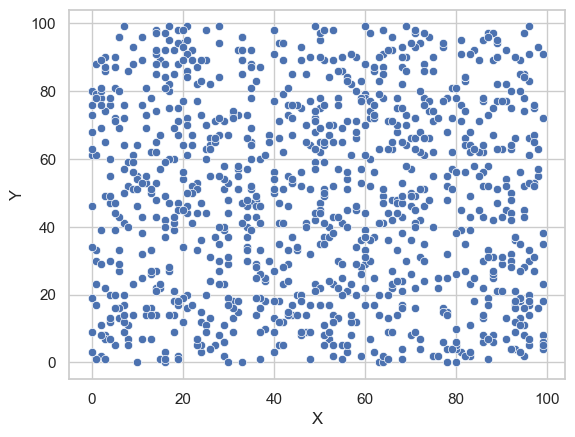

BigCodeBencho574: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


  9%|▉         | 56/594 [09:47<1:59:05, 13.28s/it]

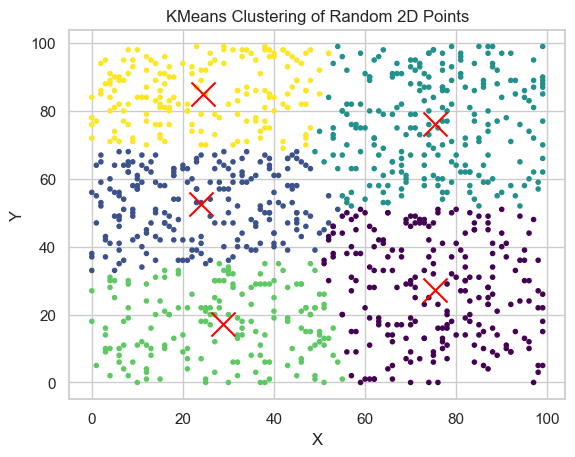

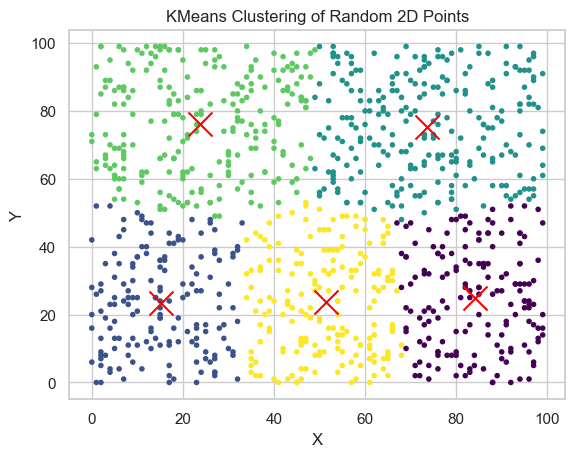

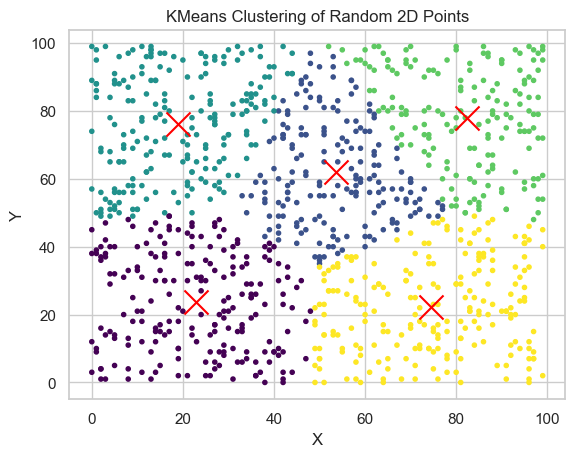

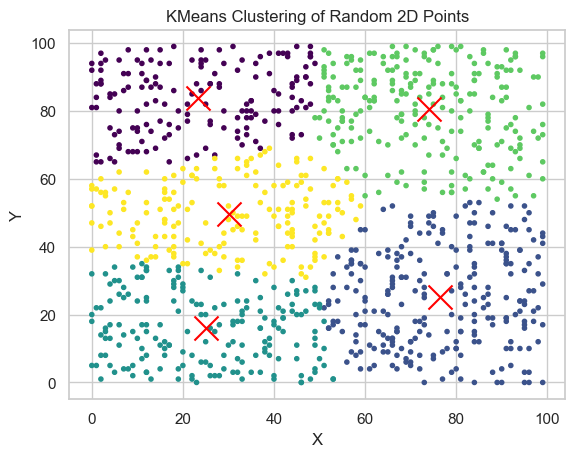

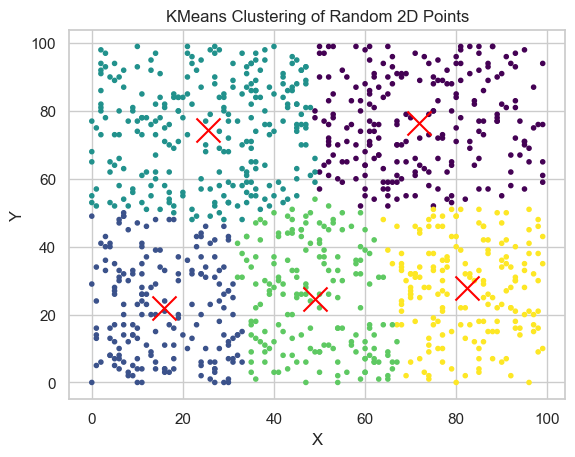

 10%|▉         | 57/594 [09:57<1:51:13, 12.43s/it]

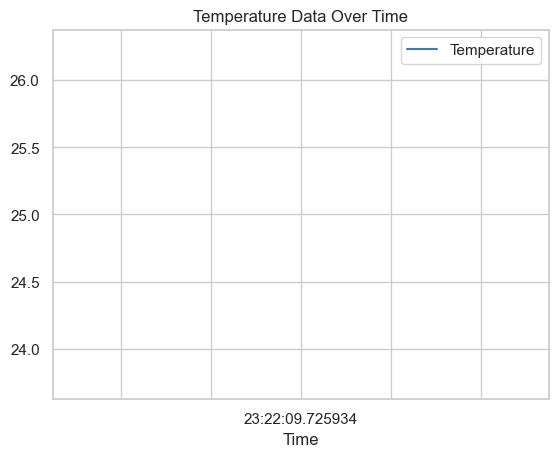

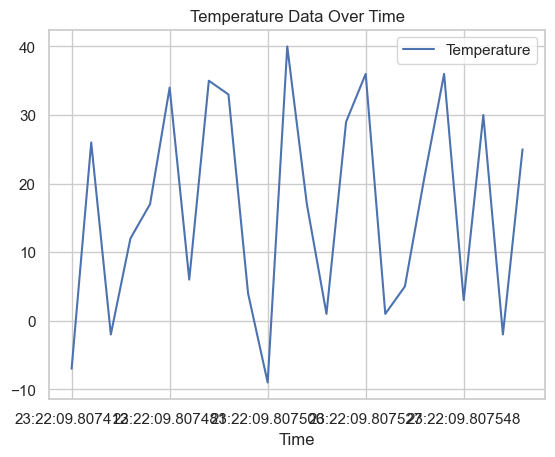

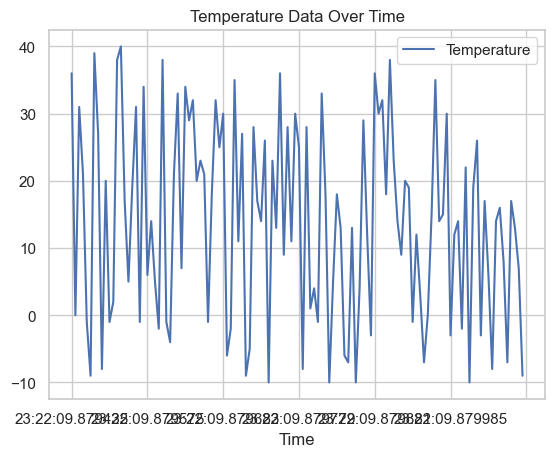

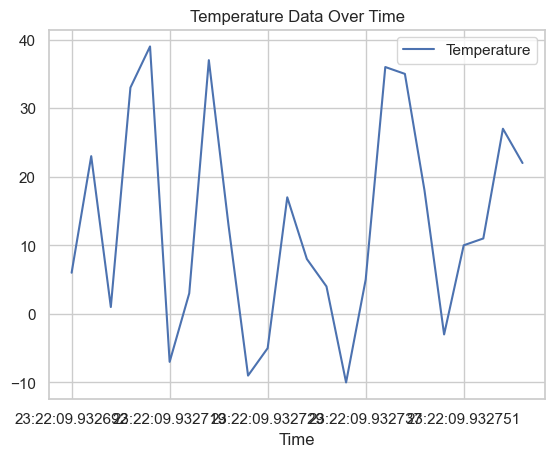

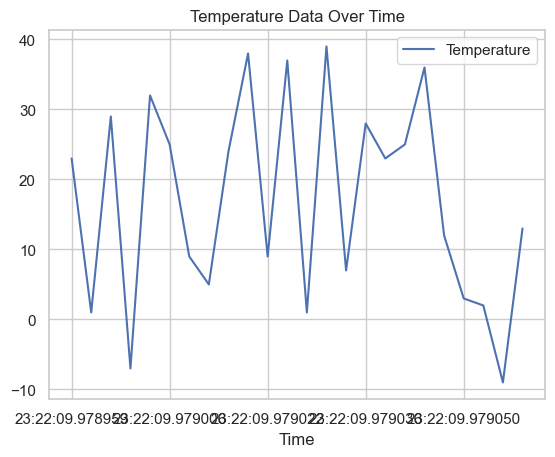

BigCodeBencho576: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 10%|▉         | 59/594 [10:17<1:38:58, 11.10s/it]

BigCodeBencho578: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 10%|█         | 61/594 [10:36<1:29:51, 10.12s/it]

BigCodeBencho580: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_case_insensitivity>, 'Traceback (most recent call last):\n  File "<string>", line 32, in test_case_insensitivity\nTypeError: unsupported operand type(s) for +: \'int\' and \'str\'\n')]


...

 11%|█         | 66/594 [11:21<1:22:56,  9.43s/it]

BigCodeBencho585: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 11%|█▏        | 68/594 [11:37<1:17:07,  8.80s/it]Undefined symbols for architecture arm64:
  "_main", referenced from:
     implicit entry/start for main executable
ld: symbol(s) not found for architecture arm64
clang: error: linker command failed with exit code 1 (use -v to see invocation)


BigCodeBencho587: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_compilation_failure>, 'Traceback (most recent call last):\n  File "/Users/jin/anaconda3/lib/python3.11/unittest/mock.py", line 1375, in patched\n    return func(*newargs, **newkeywargs)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "<string>", line 17, in test_compilation_failure\n  File "<string>", line 8, in task_func\n  File "/Users/jin/anaconda3/lib/python3.11/subprocess.py", line 571, in run\n    raise CalledProcessError(retcode, process.args,\nsubprocess.CalledProcessError: Command \'[\'g++\', \'example.cpp\', \'-o\', \'output\']\' returned non-zero exit status 1.\n'), (<builtins.TestCases testMethod=test_compiler_not_found>, 'Traceback (most recent call last):\n  File "/Users/jin/anaconda3/lib/python3.11/unittest/mock.py", line 1375, in patched\n    return func(*newargs, *

 12%|█▏        | 71/594 [12:05<1:18:44,  9.03s/it]

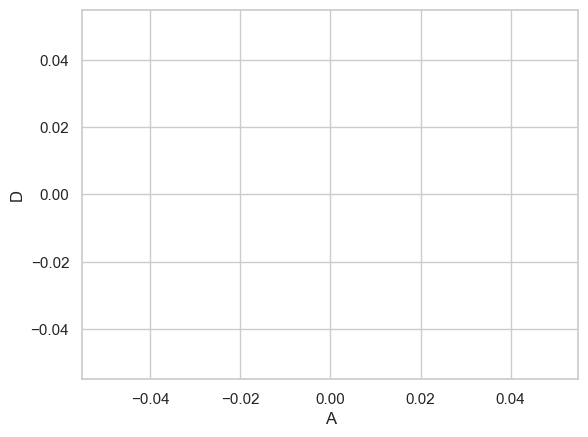

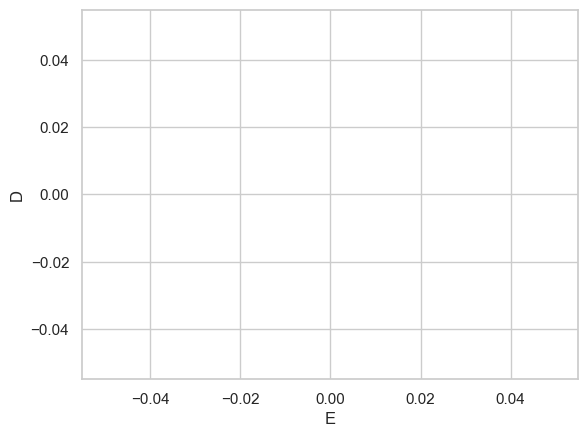

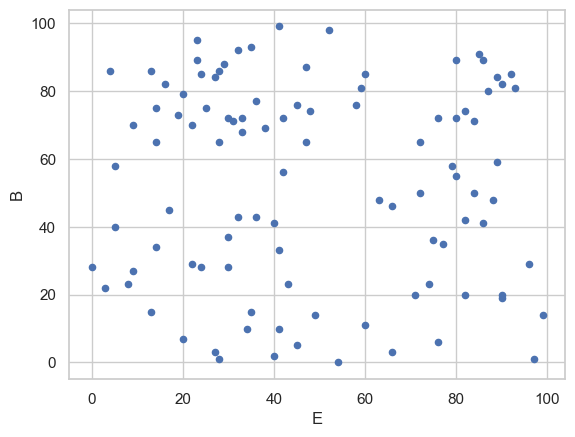

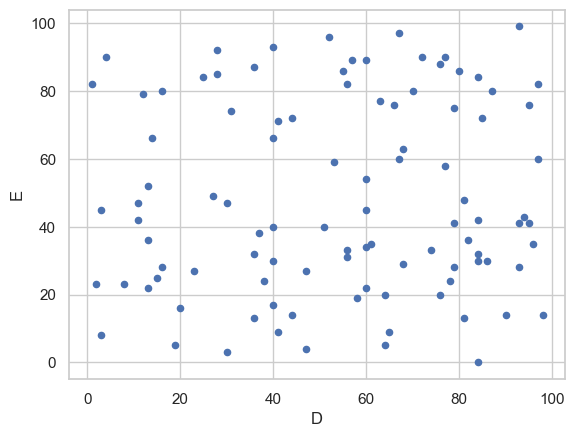

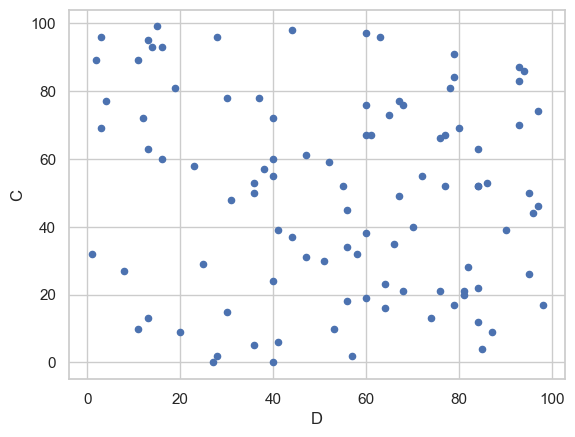

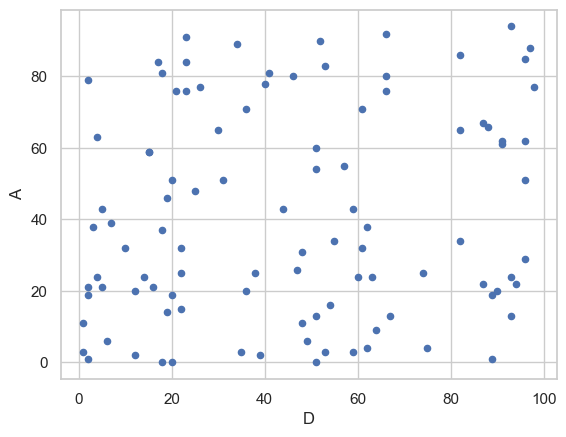

BigCodeBencho590: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 12%|█▏        | 74/594 [12:37<1:27:32, 10.10s/it]

BigCodeBencho593: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 13%|█▎        | 75/594 [12:48<1:29:42, 10.37s/it]

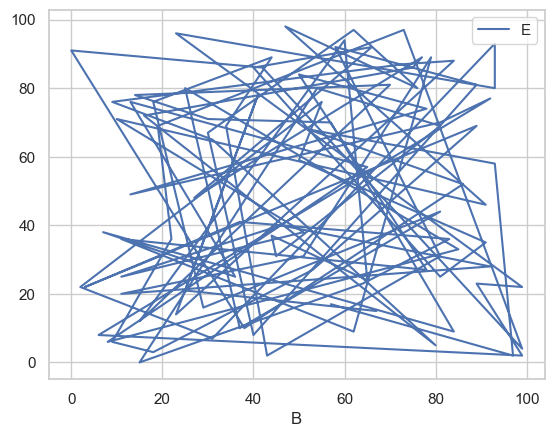

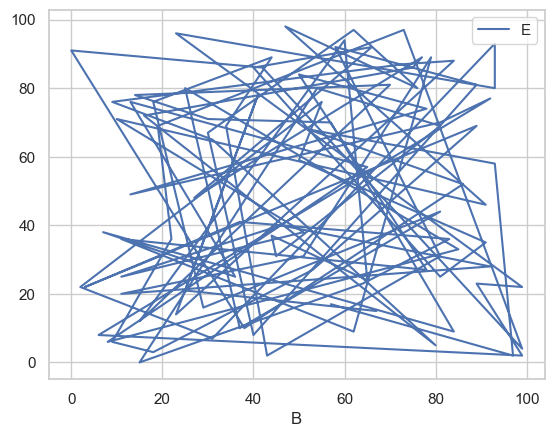

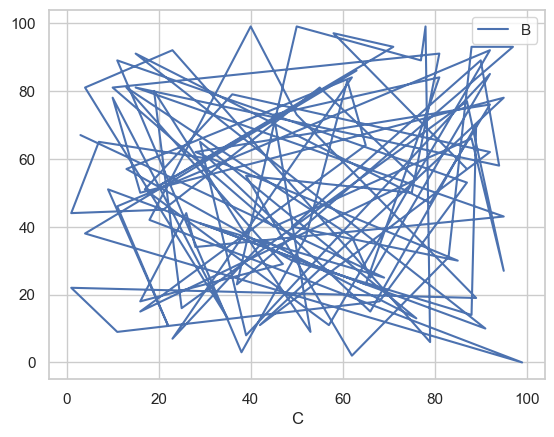

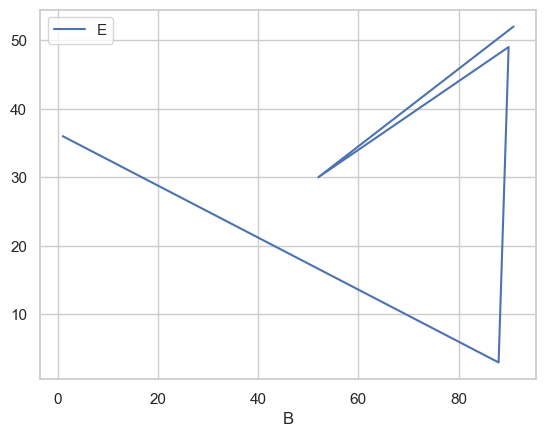

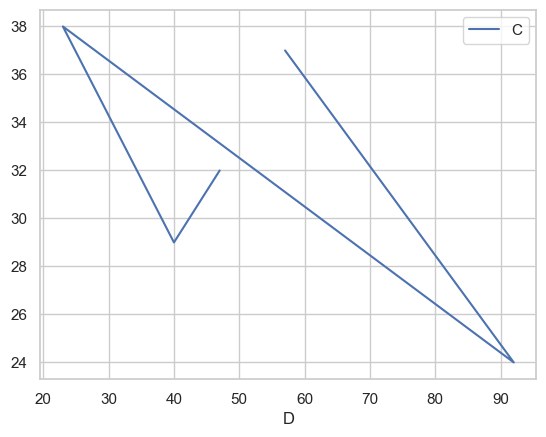

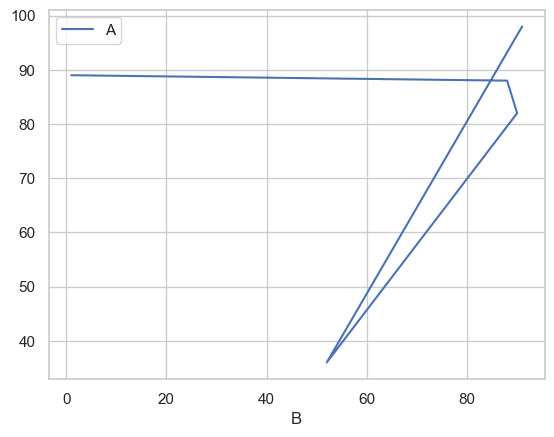

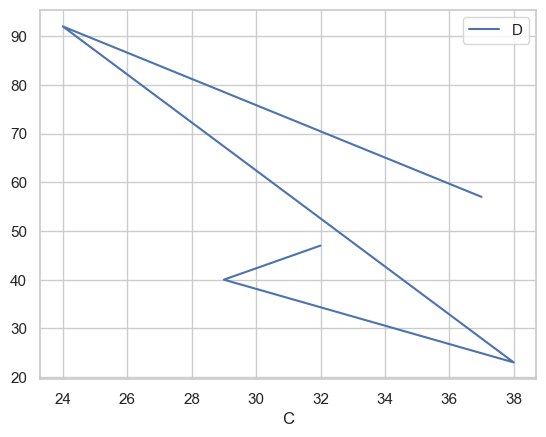

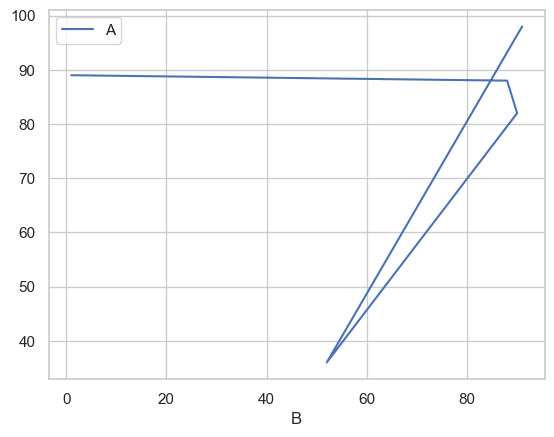

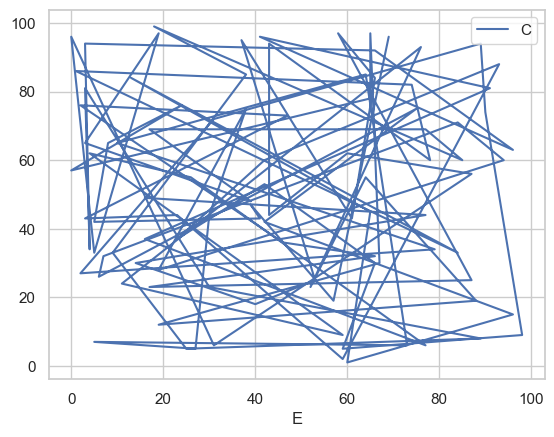

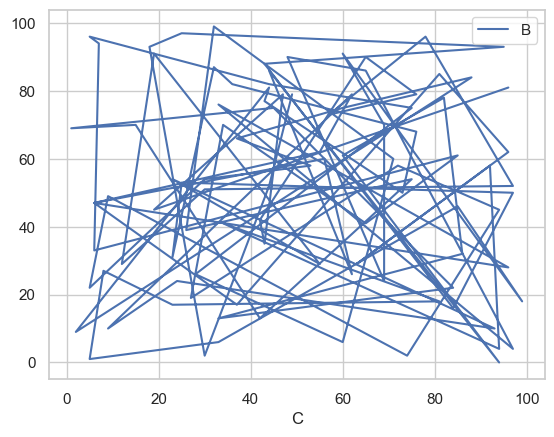

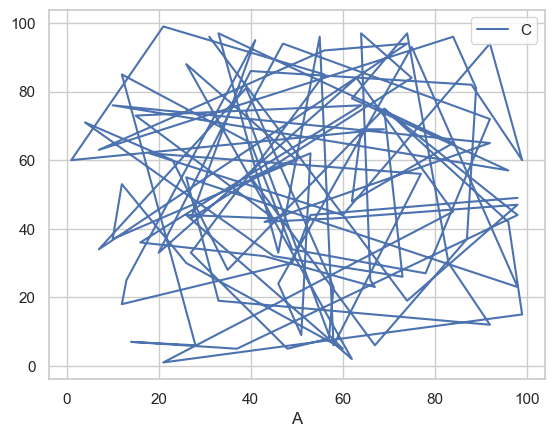

 13%|█▎        | 76/594 [12:59<1:31:14, 10.57s/it]

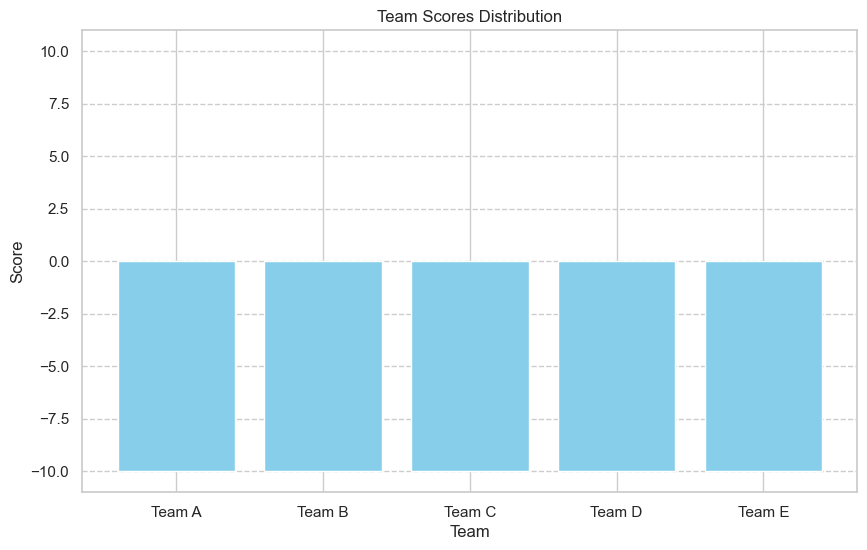

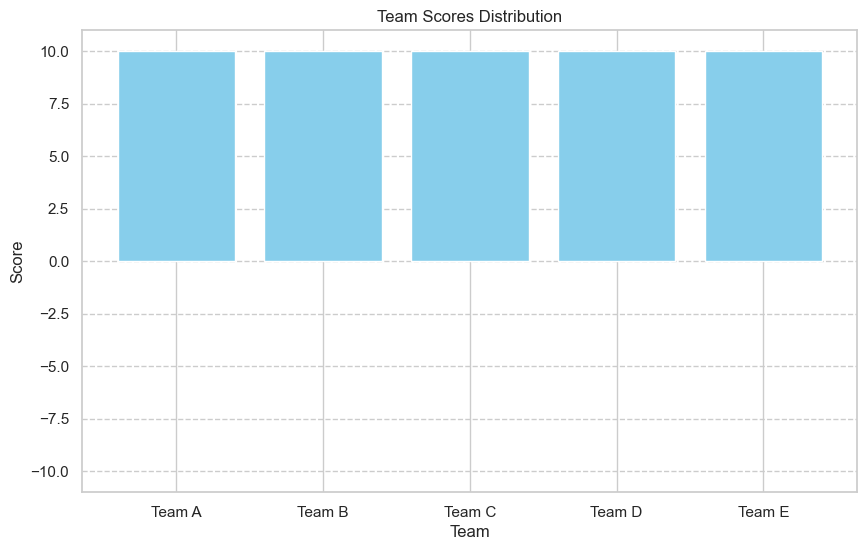

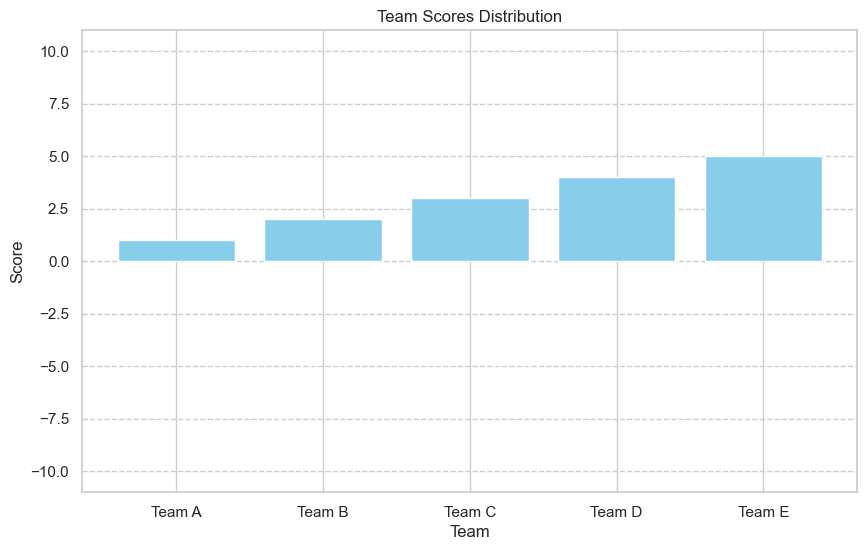

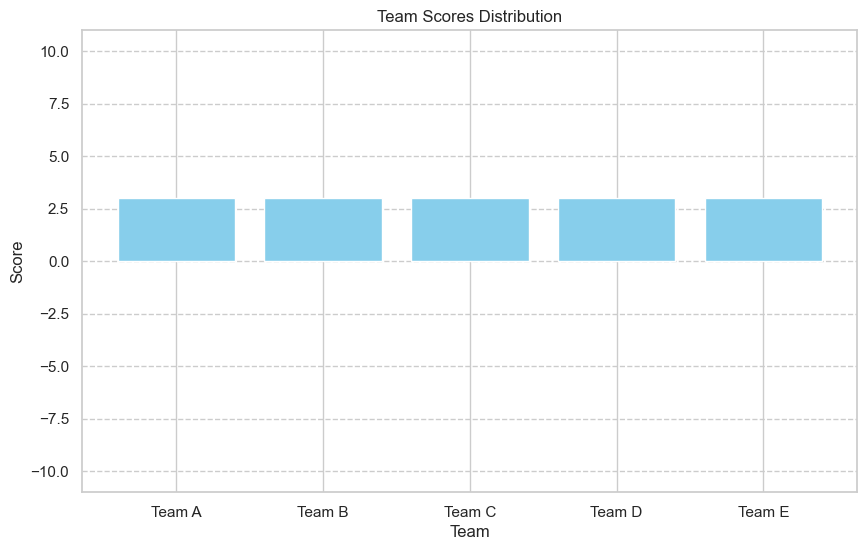

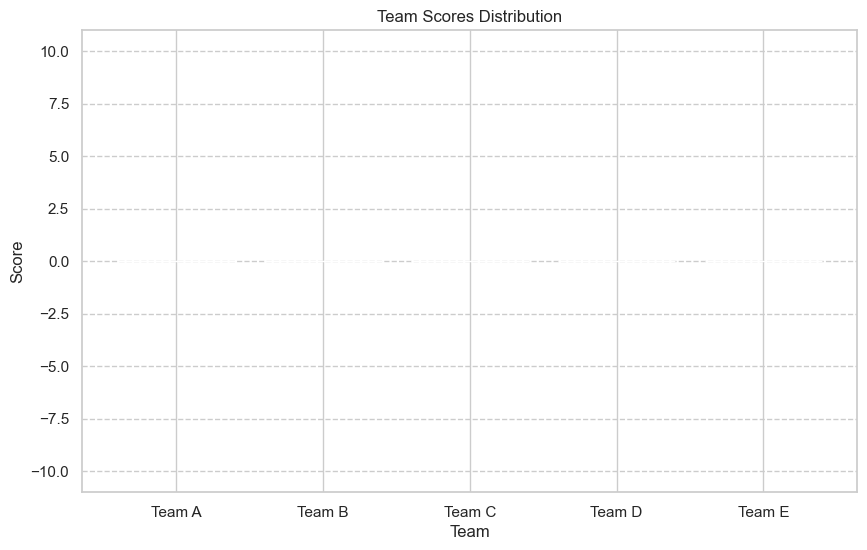

 13%|█▎        | 78/594 [13:20<1:31:22, 10.62s/it]

BigCodeBencho597: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_negative_input_handling>, 'Traceback (most recent call last):\n  File "<string>", line 27, in test_negative_input_handling\n  File "<string>", line 12, in task_func\n  File "/Users/jin/anaconda3/lib/python3.11/random.py", line 362, in randint\n    return self.randrange(a, b+1)\n           ^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/anaconda3/lib/python3.11/random.py", line 345, in randrange\n    raise ValueError("empty range for randrange() (%d, %d, %d)" % (istart, istop, width))\nValueError: empty range for randrange() (0, -4, -4)\n')]


 13%|█▎        | 79/594 [13:30<1:29:22, 10.41s/it]

BigCodeBencho598: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 13%|█▎        | 80/594 [13:39<1:26:13, 10.07s/it]

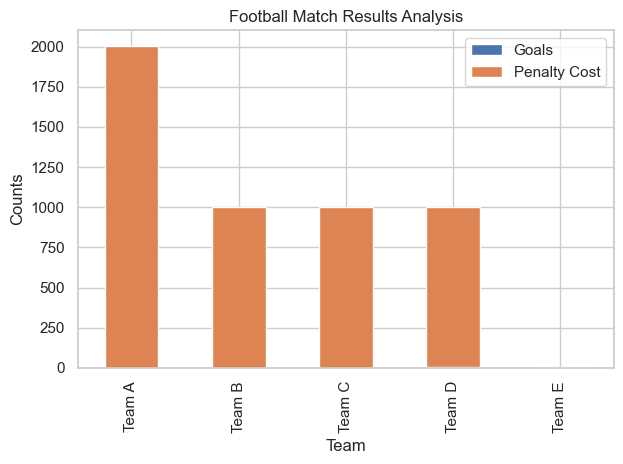

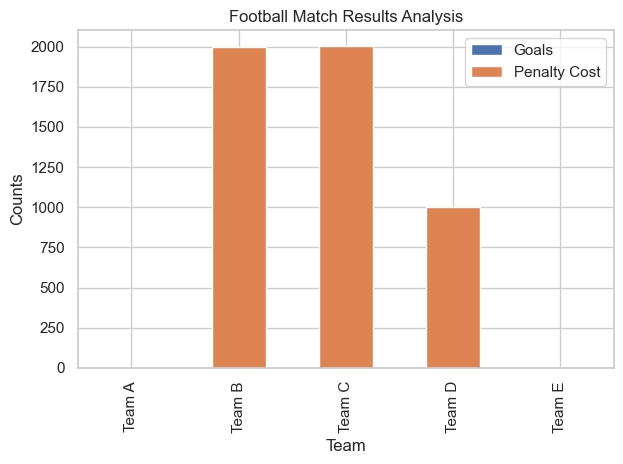

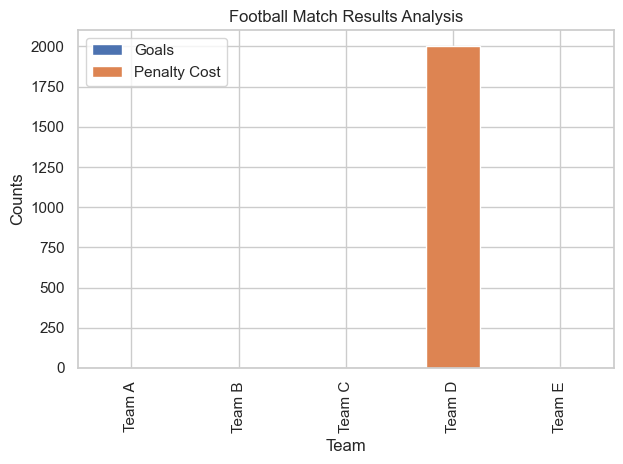

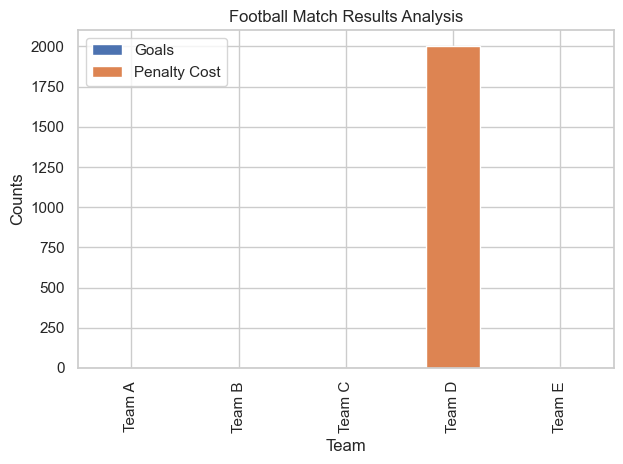

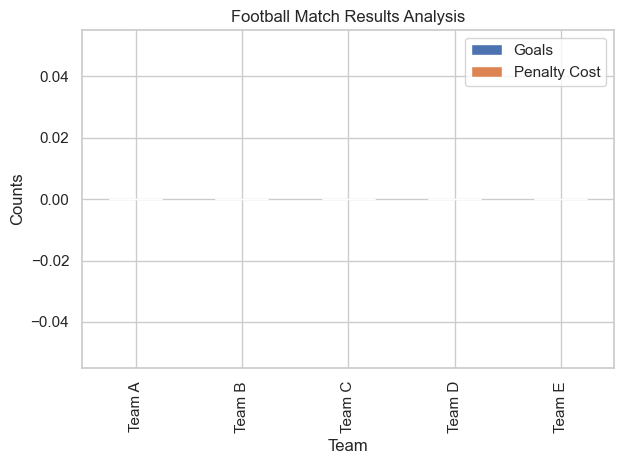

BigCodeBencho599: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unindent does not match any outer indentation level (<string>, line 4)


 14%|█▎        | 81/594 [13:53<1:35:25, 11.16s/it]

BigCodeBencho600: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 8)


 14%|█▍        | 82/594 [14:02<1:30:10, 10.57s/it]

BigCodeBencho601: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unindent does not match any outer indentation level (<string>, line 4)


...

 16%|█▋        | 97/594 [16:25<1:18:17,  9.45s/it]

BigCodeBencho616: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 16%|█▋        | 98/594 [16:36<1:21:24,  9.85s/it]

BigCodeBencho617: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 17%|█▋        | 102/594 [17:17<1:23:43, 10.21s/it]

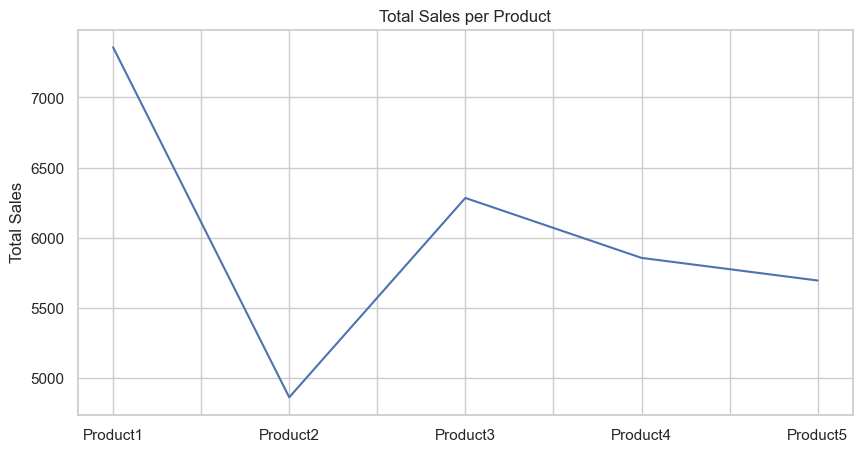

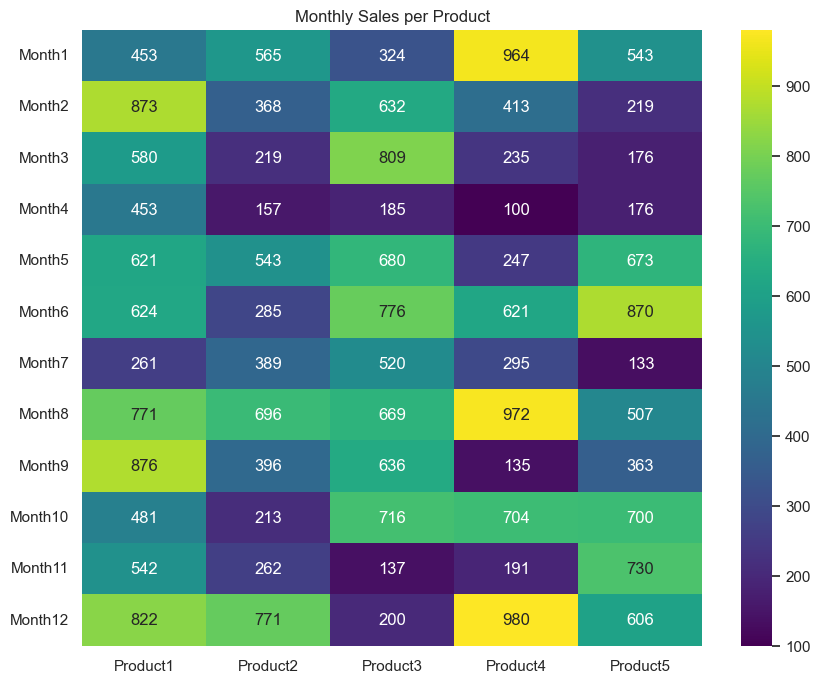

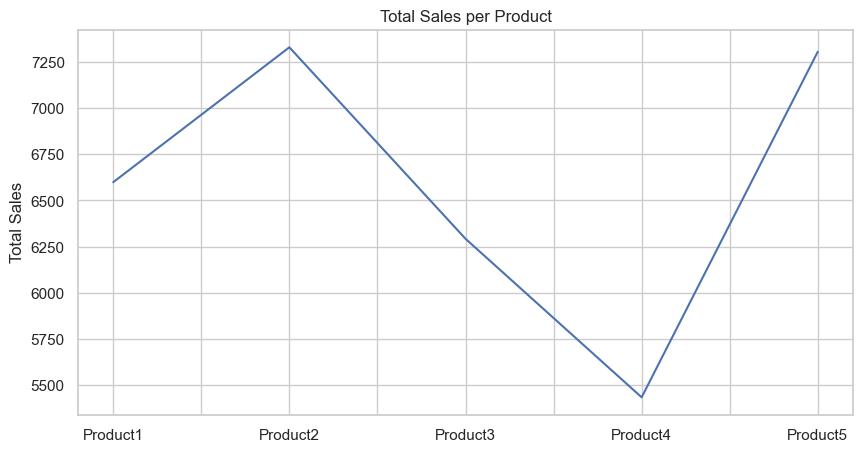

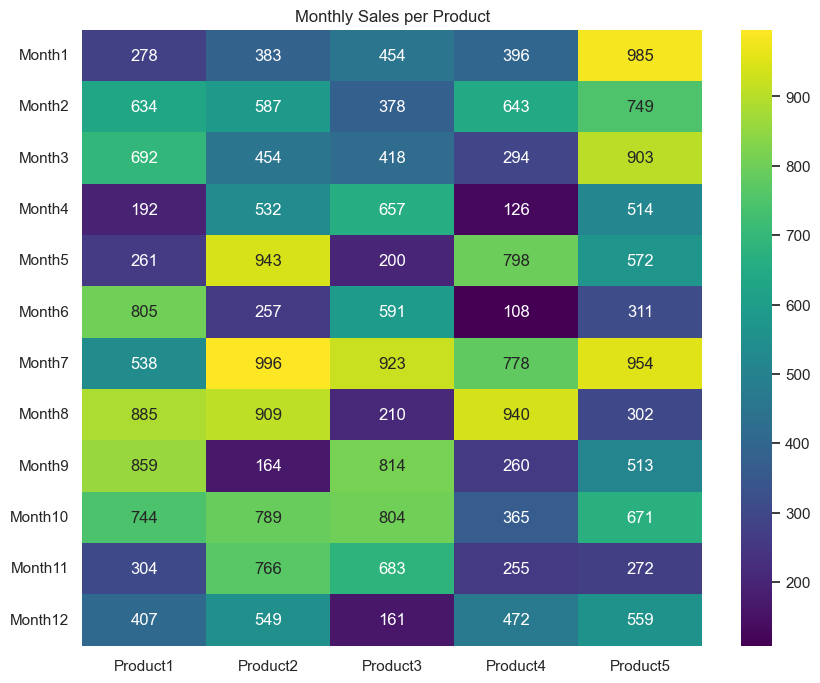

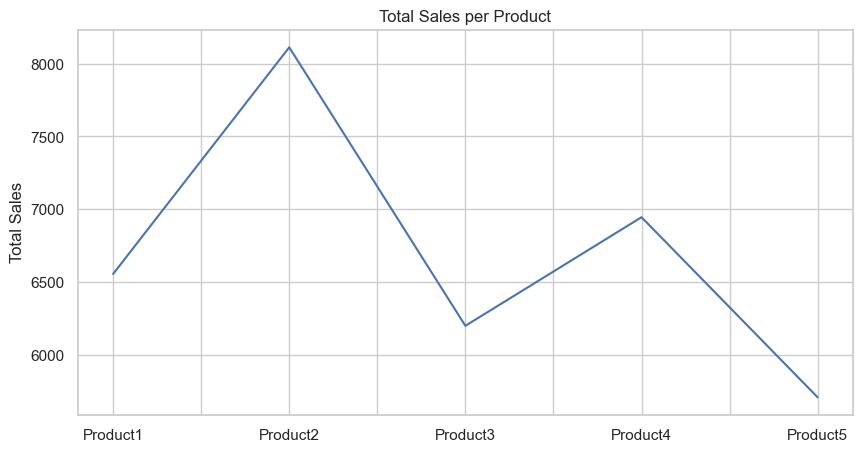

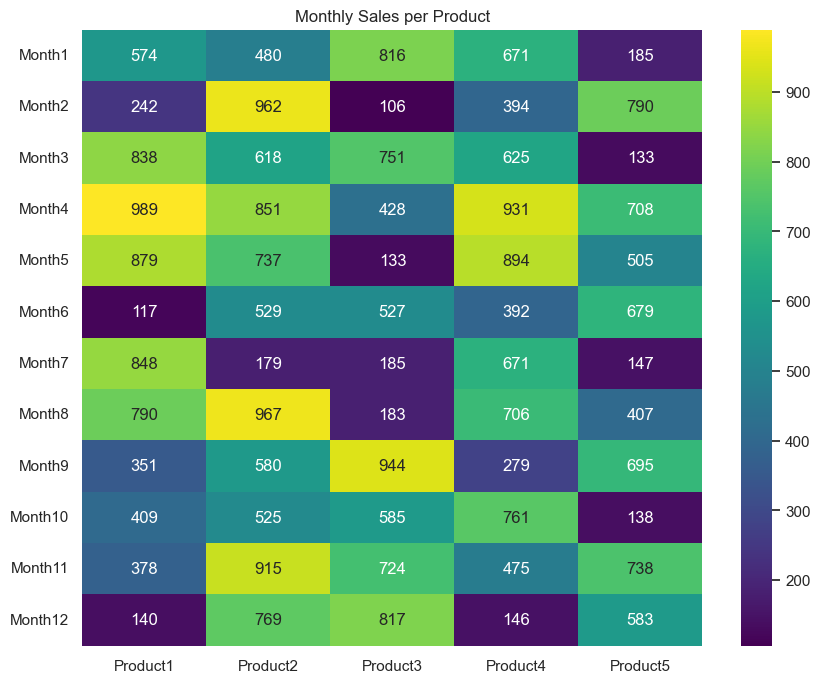

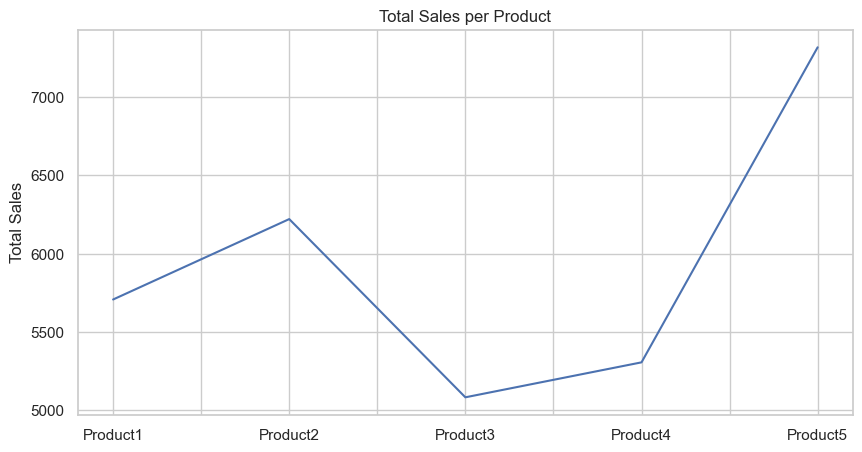

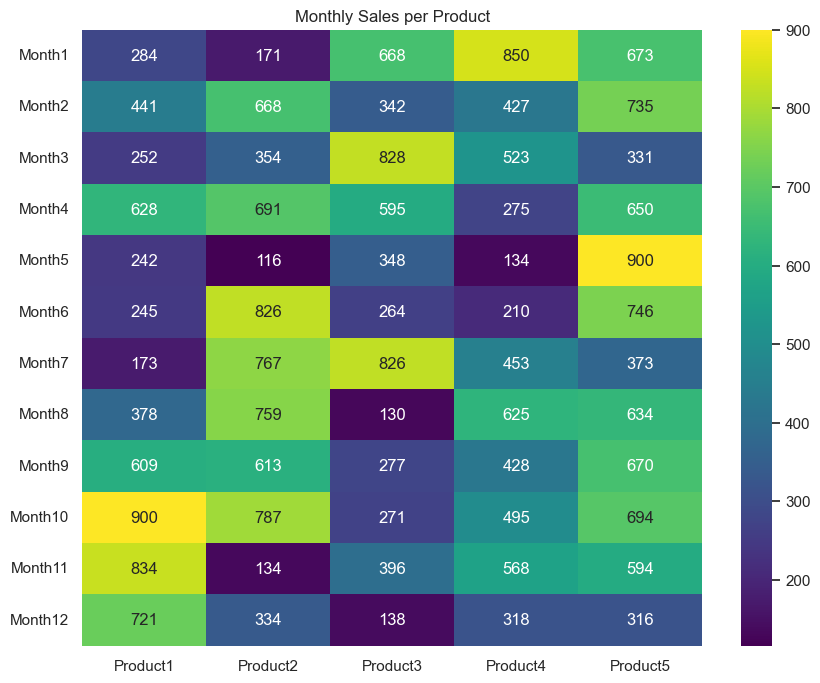

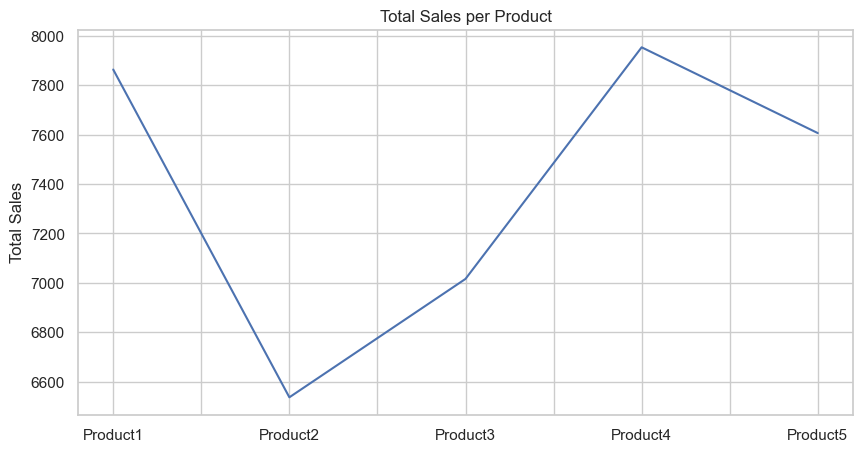

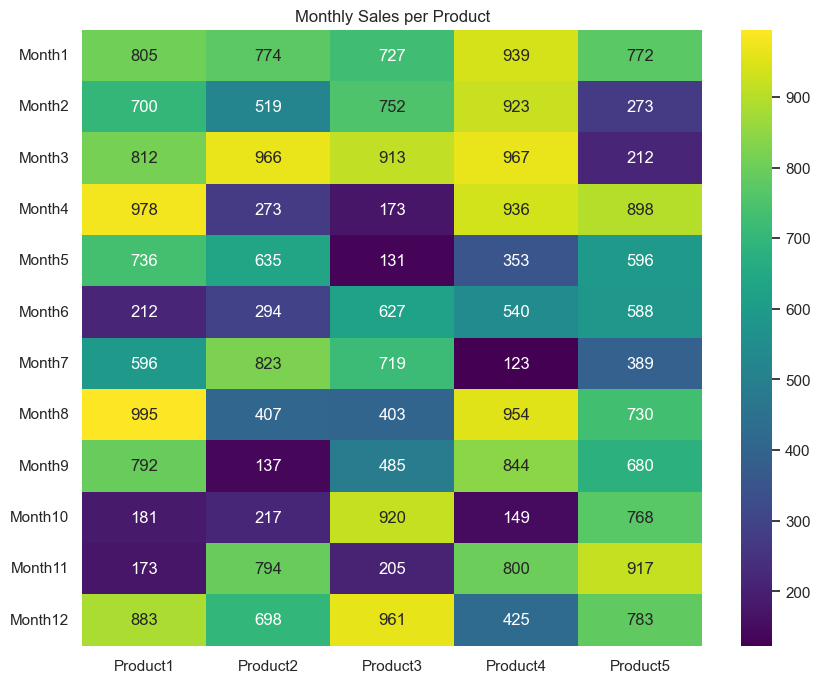

 17%|█▋        | 103/594 [17:30<1:29:39, 10.96s/it]

BigCodeBencho622: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 3)


 18%|█▊        | 105/594 [17:48<1:21:33, 10.01s/it]

BigCodeBencho624: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unindent does not match any outer indentation level (<string>, line 7)


 18%|█▊        | 107/594 [18:05<1:16:01,  9.37s/it]

BigCodeBencho626: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_empty_csv>, 'Traceback (most recent call last):\n  File "<string>", line 30, in test_empty_csv\n  File "<string>", line 8, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 1026, in read_csv\n    return _read(filepath_or_buffer, kwds)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 620, in _read\n    parser = TextFileReader(filepath_or_buffer, **kwds)\n             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/pandas/io/parsers/readers

 18%|█▊        | 108/594 [18:13<1:13:14,  9.04s/it]

BigCodeBencho627: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unindent does not match any outer indentation level (<string>, line 4)


 19%|█▉        | 114/594 [19:08<1:13:19,  9.17s/it]

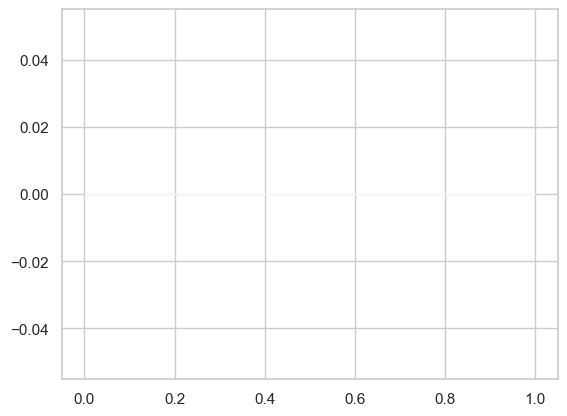

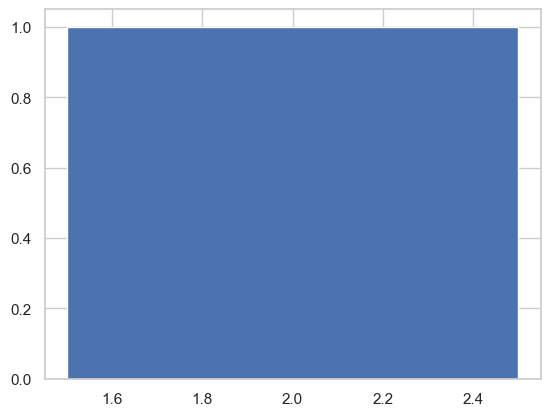

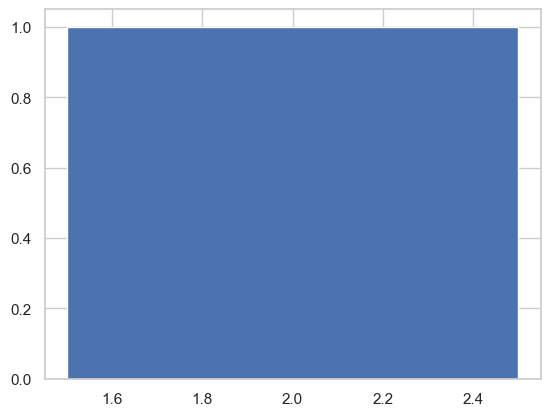

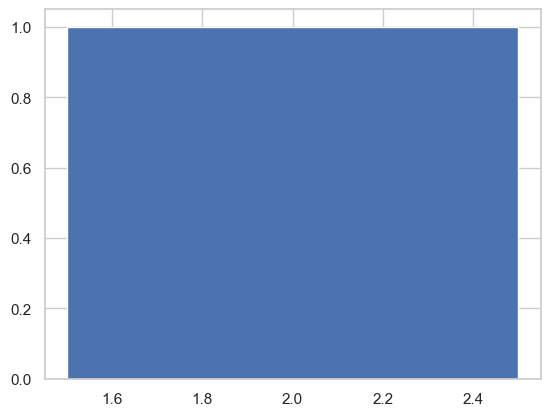

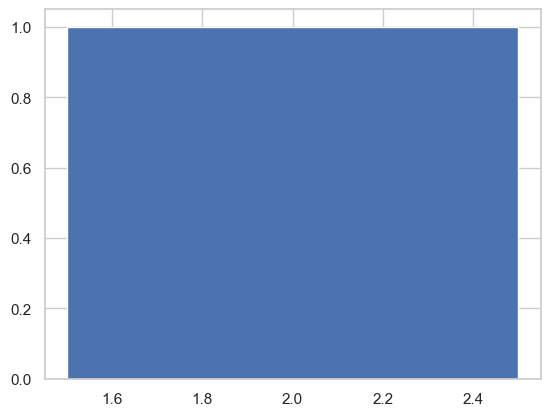

 19%|█▉        | 115/594 [19:17<1:13:29,  9.21s/it]

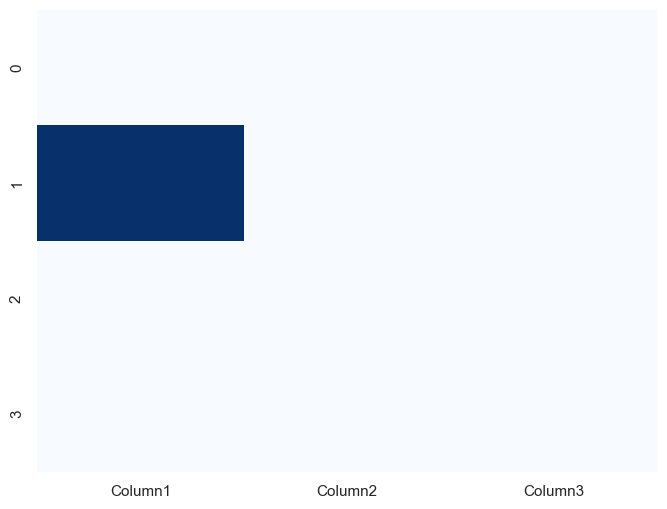

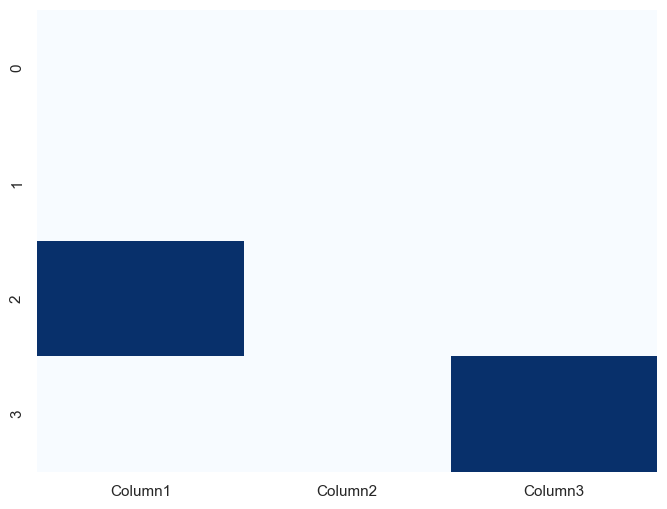

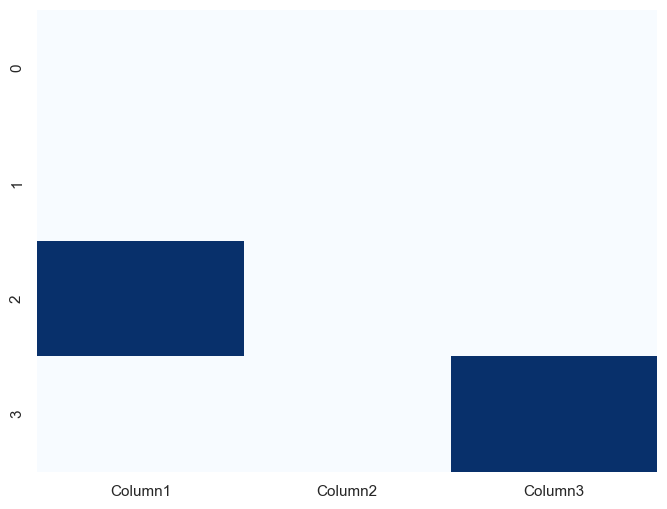

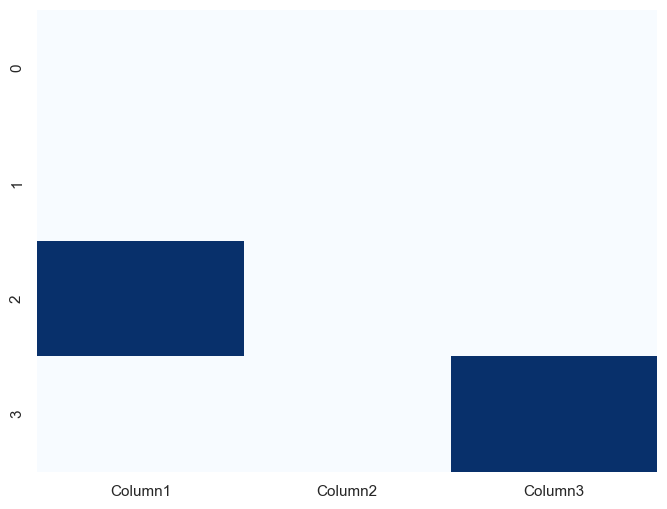

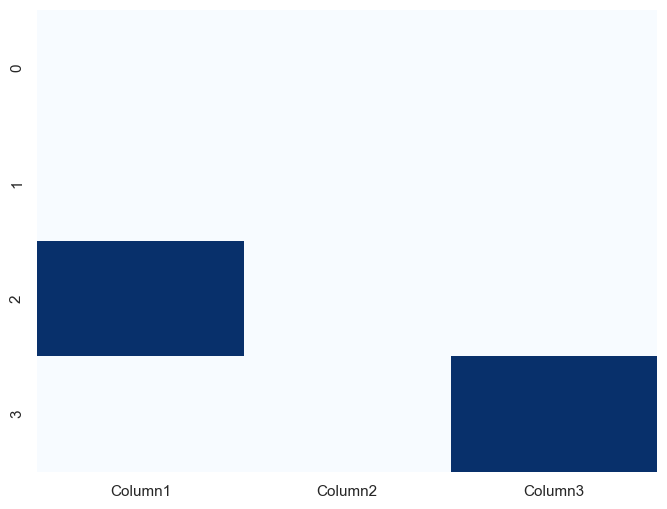

 20%|█▉        | 116/594 [19:26<1:13:38,  9.24s/it]

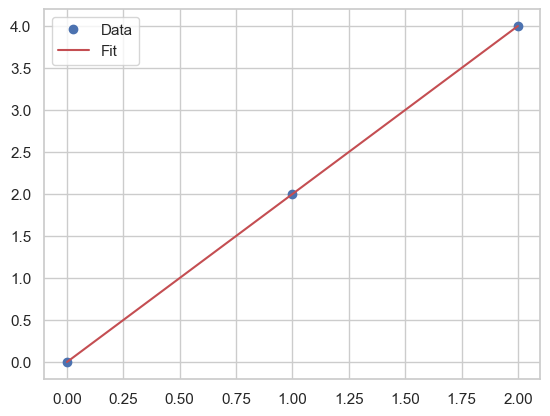

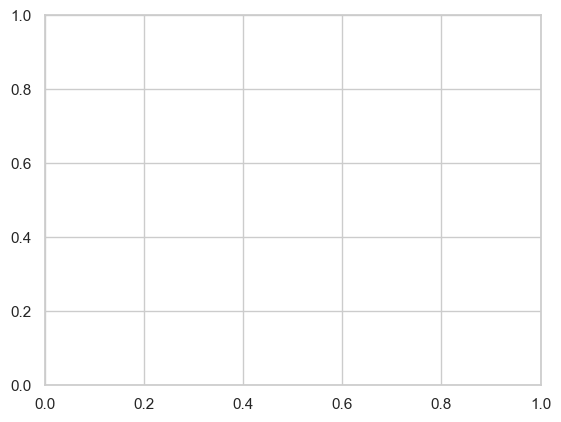

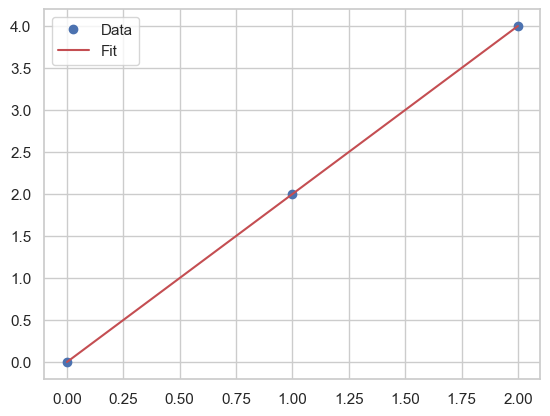

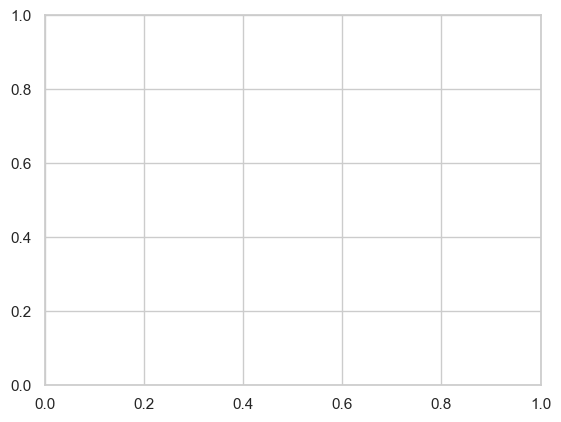

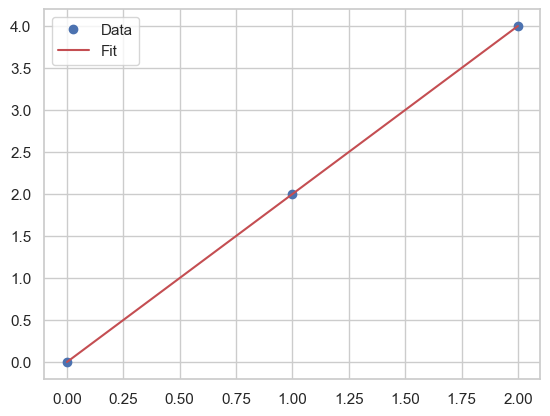

BigCodeBencho635: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_functionality>, 'Traceback (most recent call last):\n  File "<string>", line 32, in test_functionality\n  File "<string>", line 16, in task_func\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py", line 1005, in curve_fit\n    raise RuntimeError("Optimal parameters not found: " + errmsg)\nRuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.\n'), (<builtins.TestCases testMethod=test_not_enough_points>, 'Traceback (most recent call last):\n  File "<string>", line 29, in test_not_enough_points\n  File "<string>", line 9, in task_func\nIndexError: index 1 is out of bounds for axis 1 with size 1\n'), (<builtins.TestCases testMethod=test_return_types>, 'Trace

 20%|█▉        | 117/594 [19:38<1:18:33,  9.88s/it][nltk_data] Downloading package stopwords to /Users/jin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


BigCodeBencho636: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 20%|█▉        | 118/594 [19:48<1:19:34, 10.03s/it][nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


BigCodeBencho637: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


...

BigCodeBencho777: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unexpected indent (<string>, line 2)


 44%|████▍     | 262/594 [42:55<52:48,  9.54s/it]

BigCodeBencho781: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: IndentationError > unindent does not match any outer indentation level (<string>, line 11)


 44%|████▍     | 263/594 [43:35<54:51,  9.94s/it]

cannot access local variable 'e' where it is not associated with a value
BigCodeBencho782
Results saved in /Users/jin/Documents/GitHub/Code Reasoning Model Research Project/results/code_generation/gpt-4o/BigCodeBench_one_shot_no_mutation.csv


In [10]:
# %%script false --no-raise-error
mutations = []
prompt_type = ONE_SHOT
model_name = GPT4O

# Forming the results directory
results_dir =os.path.join(proj_dir, f'results/code_generation/{model_name}')
os.makedirs(results_dir, exist_ok=True)

mutation_str = "_".join(mutations) if len(mutations) > 0 else "no_mutation"
output_file_path=f"{results_dir}/{task_set}_{prompt_type}_{mutation_str}.csv"

pass_count = llmtester.run_code_generation_test(
    prompt_helper = OpenEndedPromptTemplate().return_appropriate_prompt(prompt_type),
    num_tests=num_tests,
    mutations = mutations,
    prompt_type= prompt_type,
    output_file_path=output_file_path,
    task_set = task_set,
    model_name= model_name,
    continue_from_task="BigCodeBencho519"
)

print(fr"Results saved in {output_file_path}")


In [15]:
# %%script false --no-raise-error
mutations = [RANDOM_MUTATION]
prompt_type = ONE_SHOT
model_name = GPT4O

# Forming the results directory
results_dir =os.path.join(proj_dir, f'results/code_generation/{model_name}')
os.makedirs(results_dir, exist_ok=True)

mutation_str = "_".join(mutations) if len(mutations) > 0 else "no_mutation"
output_file_path=f"{results_dir}/{task_set}_{prompt_type}_{mutation_str}.csv"

pass_count = llmtester.run_code_generation_test(
    prompt_helper = OpenEndedPromptTemplate().return_appropriate_prompt(prompt_type),
    num_tests=num_tests,
    mutations = mutations,
    prompt_type= prompt_type,
    output_file_path=output_file_path,
    task_set = task_set,
    model_name= model_name,
    continue_from_task="BigCodeBencho282"
)

print(fr"Results saved in {output_file_path}")


BigCodeBencho282: Function failed to run due to following error -> LLM solution failed due to following error: str > LLM solution failed due to following error: list > [(<builtins.TestCases testMethod=test_case_1>, 'Traceback (most recent call last):\n  File "<string>", line 5, in test_case_1\n  File "<string>", line 12, in crkjL\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/matplotlib/axes/_base.py", line 1514, in __getitem__\n    return [artist\n           ^^^^^^^\nIndexError: list index out of range\n'), (<builtins.TestCases testMethod=test_case_2>, 'Traceback (most recent call last):\n  File "<string>", line 12, in test_case_2\n  File "<string>", line 12, in crkjL\n  File "/Users/jin/Documents/GitHub/Code Reasoning Model Research Project/venv/lib/python3.11/site-packages/matplotlib/axes/_base.py", line 1514, in __getitem__\n    return [artist\n           ^^^^^^^\nIndexError: list index out of range\n'), (<builtins.TestC